# DocTalk Chat Corpus: Analyses of direct messages
Author: Sabine Sayegh-Jodehl <br>

Version 3.0

Python 3.11.10 Mac OS
____________________________________________________________

# Notbook set up

In [2]:
# Determine which environment is being used in the notebook
import sys
print(sys.executable)

/Users/sayegh-jodehl/Documents/Publikationen/Korpusanalyse_JMIR/Code_KorpusAnalyse/.venv/bin/python


In [3]:
#check if all requirements are present
import sys
print(sys.executable)

!{sys.executable} -m pip list

/Users/sayegh-jodehl/Documents/Publikationen/Korpusanalyse_JMIR/Code_KorpusAnalyse/.venv/bin/python
Package                   Version
------------------------- -----------
aiohappyeyeballs          2.6.2
aiohttp                   3.13.5
aiosignal                 1.4.0
annotated-doc             0.0.4
annotated-types           0.7.0
anyio                     4.13.0
appnope                   0.1.4
argon2-cffi               25.1.0
argon2-cffi-bindings      25.1.0
arrow                     1.4.0
asttokens                 3.0.1
async-lru                 2.3.0
attrs                     26.1.0
babel                     2.18.0
beautifulsoup4            4.14.3
bleach                    6.3.0
blis                      1.3.3
Bottleneck                1.6.0
catalogue                 2.0.10
certifi                   2026.5.20
cffi                      2.0.0
charset-normalizer        3.4.7
clean-text                0.7.1
click                     8.4.1
cloudpathlib              0.24.0
comm           

In [60]:
# write requirements to file
import sys

!{sys.executable} -m pip freeze > requirements.txt

In [5]:
# Überprüfen, ob alle requirements da sind
import sys
print(sys.executable)

!{sys.executable} -m pip list
!{sys.executable} -m pip freeze | wc -l

/Users/sayegh-jodehl/Documents/Publikationen/Korpusanalyse_JMIR/Code_KorpusAnalyse/.venv/bin/python
Package                   Version
------------------------- -----------
aiohappyeyeballs          2.6.2
aiohttp                   3.13.5
aiosignal                 1.4.0
annotated-doc             0.0.4
annotated-types           0.7.0
anyio                     4.13.0
appnope                   0.1.4
argon2-cffi               25.1.0
argon2-cffi-bindings      25.1.0
arrow                     1.4.0
asttokens                 3.0.1
async-lru                 2.3.0
attrs                     26.1.0
babel                     2.18.0
beautifulsoup4            4.14.3
bleach                    6.3.0
blis                      1.3.3
Bottleneck                1.6.0
catalogue                 2.0.10
certifi                   2026.5.20
cffi                      2.0.0
charset-normalizer        3.4.7
clean-text                0.7.1
click                     8.4.1
cloudpathlib              0.24.0
comm           

## Working directory

In [6]:
# Checking the current working directory

import os
os.getcwd()

'/Users/sayegh-jodehl/Documents/Publikationen/Korpusanalyse_JMIR/Code_KorpusAnalyse/1_An_direktNachrichten'

## Loading modules <br>
List of modules: convokit, nltk, pandas, spacy, os, datetime, gensim

For working with ConvoKit necessary:
- Download the toolkit: pip3 install convokit
- Download Spacy's English model: python3 -m spacy download en (convert for German [spacy_model = "de_core_news_sm"]) <br>
- Download NLTK's 'punkt' model: import nltk; nltk.download('punkt') (in Python interpreter)

In [7]:
%pip install --upgrade pip;
%pip install notebook --upgrade;
%pip install nbconvert --upgrade;
%pip install pandas --upgrade;

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


In [8]:
%pip install torch --extra-index-url https://download.pytorch.org/whl/cpu

Looking in indexes: https://pypi.org/simple, https://download.pytorch.org/whl/cpu
Note: you may need to restart the kernel to use updated packages.


In [9]:
import sys
print(sys.executable)

/Users/sayegh-jodehl/Documents/Publikationen/Korpusanalyse_JMIR/Code_KorpusAnalyse/.venv/bin/python


In [10]:
%pip install matplotlib

Note: you may need to restart the kernel to use updated packages.


In [11]:
import numpy as np
import pandas as pd
import datetime as dt
import matplotlib as mpl

In [12]:
import matplotlib
import matplotlib.pyplot as plt
print(matplotlib.__version__)

3.10.9


In [13]:
# adapt picture resolution

%config InlineBackend.figure_format = 'retina'
import matplotlib.pyplot as plt
import numpy as np



In [14]:
%pip install wordcloud
%pip install nltk

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


In [15]:
import wordcloud as wc
import os
import nltk

In [16]:
%pip install spacy --upgrade

Note: you may need to restart the kernel to use updated packages.


In [17]:
!python3 -m spacy download en_core_web_sm

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 27.3 MB/s  0:00:00 eta 0:00:01
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')


In [18]:
import nltk
nltk.download('punkt')

[nltk_data] Downloading package punkt to /Users/sayegh-
[nltk_data]     jodehl/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


True

### Notwendige Modelle für Spacy und nltk

In [19]:
import os
import importlib
import nltk
import subprocess

# Liste der Module, die überprüft und gegebenenfalls installiert werden sollen
spacy_model = "de_core_news_sm"
nltk_data = "punkt"

# Überprüfe und installiere das spaCy-Modell
try:
    importlib.import_module(spacy_model)
    print(f"{spacy_model} ist bereits installiert.")
except ImportError:
    print(f"{spacy_model} ist nicht installiert. Installiere es jetzt.")

    # Modell mit spaCy herunterladen
    subprocess.call(["python", "-m", "spacy", "download", spacy_model])

# Überprüft und installiert die NLTK-Daten
if nltk.download(nltk_data):
    print(f"NLTK-Daten ({nltk_data}) wurden heruntergeladen.")
else:
    print(f"NLTK-Daten ({nltk_data}) sind bereits vorhanden.")

de_core_news_sm ist bereits installiert.
NLTK-Daten (punkt) wurden heruntergeladen.


[nltk_data] Downloading package punkt to /Users/sayegh-
[nltk_data]     jodehl/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


In [20]:
%pip install --upgrade convokit 

Note: you may need to restart the kernel to use updated packages.


In [21]:
import convokit

In [22]:
# dealing with excel files
%pip install pandas openpyxl

Note: you may need to restart the kernel to use updated packages.


In [23]:
import openpyxl

## Setup: paths

In [24]:
from pathlib import Path
import pandas as pd
import os

# =========================
# Notebook setup: paths
# =========================

# Current notebook directory
NOTEBOOK_DIR = Path.cwd()

# Project root directory
PROJECT_DIR = NOTEBOOK_DIR.parent

# Input directories
DIRECT_DATA_DIR = PROJECT_DIR / "data" / "direct"
GROUP_DATA_DIR = PROJECT_DIR / "data" / "group"

# Output base directory
OUTPUT_DIR = NOTEBOOK_DIR / "output"

# Separate output directories
DF_OUTPUT_DIR = OUTPUT_DIR / "DF"
CORPUS_OUTPUT_DIR = OUTPUT_DIR / "corpus_objects"

# Create output directories if they do not exist
DF_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
CORPUS_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# Shared output directories for comparative result tables and figures
RESULTS_OUTPUT_DIR = PROJECT_DIR / "output" / "results"

RESULT_TABLE_DIR = RESULTS_OUTPUT_DIR / "tables"
FIGURE_OUTPUT_DIR = RESULTS_OUTPUT_DIR / "figures"

# Create result output directories if they do not exist
RESULT_TABLE_DIR.mkdir(parents=True, exist_ok=True)
FIGURE_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)


# Check paths
print("Notebook directory:", NOTEBOOK_DIR)
print("Project directory:", PROJECT_DIR)

print("\nInput directories:")
print("Direct data:", DIRECT_DATA_DIR, "| exists:", DIRECT_DATA_DIR.exists())
print("Group data:", GROUP_DATA_DIR, "| exists:", GROUP_DATA_DIR.exists())

print("\nOutput directories:")
print("DataFrames:", DF_OUTPUT_DIR)
print("Corpus objects:", CORPUS_OUTPUT_DIR)

print("Result table directory:", RESULT_TABLE_DIR)
print("Figure output directory:", FIGURE_OUTPUT_DIR)

Notebook directory: /Users/sayegh-jodehl/Documents/Publikationen/Korpusanalyse_JMIR/Code_KorpusAnalyse/1_An_direktNachrichten
Project directory: /Users/sayegh-jodehl/Documents/Publikationen/Korpusanalyse_JMIR/Code_KorpusAnalyse

Input directories:
Direct data: /Users/sayegh-jodehl/Documents/Publikationen/Korpusanalyse_JMIR/Code_KorpusAnalyse/data/direct | exists: True
Group data: /Users/sayegh-jodehl/Documents/Publikationen/Korpusanalyse_JMIR/Code_KorpusAnalyse/data/group | exists: True

Output directories:
DataFrames: /Users/sayegh-jodehl/Documents/Publikationen/Korpusanalyse_JMIR/Code_KorpusAnalyse/1_An_direktNachrichten/output/DF
Corpus objects: /Users/sayegh-jodehl/Documents/Publikationen/Korpusanalyse_JMIR/Code_KorpusAnalyse/1_An_direktNachrichten/output/corpus_objects
Result table directory: /Users/sayegh-jodehl/Documents/Publikationen/Korpusanalyse_JMIR/Code_KorpusAnalyse/output/results/tables
Figure output directory: /Users/sayegh-jodehl/Documents/Publikationen/Korpusanalyse_JM

---

# Creating a corpus object: preparation and data cleaning

Folder with chat logs: "data/direct" <br>

Creating a DataFrame for Conversation ID with metadata <br>
Reading chat logs into a DataFrame <br>
Adjusting the DataFrame for the Corpus object for ConvoKit


## create pandas DF for Conversation-ID and add metadata for Conversation ID

1. Specify the path to the directory
2. Create an empty DataFrame for the results with defined columns
3. Search through the CSV files, first 6 rows
4. Define columns and data
5. Combine the individual DataFrames into the final result


In [25]:
# Create empty result DataFrame
D_Meta_result_df = pd.DataFrame(columns=[
    "conversation_id",
    "Channel Name",
    "Channel Type",
    "Team Name",
    "Anonymized",
    "Format"
])

print("Input directory:", DIRECT_DATA_DIR)
print("Input directory exists:", DIRECT_DATA_DIR.exists())
print("Output directory:", DF_OUTPUT_DIR)

# Browsing the files in the input directory
for file_path in DIRECT_DATA_DIR.glob("*.csv"):

    # Use filename without extension as Channel ID
    channel_id = file_path.stem

    # Read the first 6 rows of the CSV file
    D_metadata_df = pd.read_csv(
        file_path,
        nrows=6,
        header=None,
        sep=";",
        encoding="ISO-8859-1"
    )

    # Transpose DataFrame
    D_metadata_df = D_metadata_df.T

    # Use the first row as column names
    D_metadata_df.columns = D_metadata_df.iloc[0]

    # Use the second row as data
    D_metadata_df = D_metadata_df.iloc[1:2]

    # Add "Team Name" if the column is missing
    if "Team Name" not in D_metadata_df.columns:
        D_metadata_df["Team Name"] = "none"

    # Make sure all required columns exist
    for col in D_Meta_result_df.columns:
        if col not in D_metadata_df.columns:
            D_metadata_df[col] = None

    # If "Format" or "Encoding" is in the column names, use it as format column
    format_column = next(
        (col for col in D_metadata_df.columns if "Format" in col or "Encoding" in col),
        None
    )

    # Add metadata to result DataFrame
    metadata_dict = {
        "conversation_id": channel_id,
        "Channel Name": D_metadata_df["Channel Name"].iloc[0],
        "Channel Type": D_metadata_df["Channel Type"].iloc[0],
        "Team Name": D_metadata_df["Team Name"].iloc[0],
        "Anonymized": D_metadata_df["Anonymized"].iloc[0] if "Anonymized" in D_metadata_df.columns else None,
        "Format": D_metadata_df[format_column].iloc[0] if format_column else None
    }

    D_Meta_result_df = pd.concat(
        [D_Meta_result_df, pd.DataFrame(metadata_dict, index=[0])],
        ignore_index=True
    )

# Show metadata DataFrame as table in Jupyter
display(D_Meta_result_df)

# Save metadata DataFrame as Excel file
D_Meta_result_df.to_excel(
    DF_OUTPUT_DIR / "D_Meta_result_df.xlsx",
    index=False
)

print("Saved DataFrame to:")
print(DF_OUTPUT_DIR / "D_Meta_result_df.xlsx")

Input directory: /Users/sayegh-jodehl/Documents/Publikationen/Korpusanalyse_JMIR/Code_KorpusAnalyse/data/direct
Input directory exists: True
Output directory: /Users/sayegh-jodehl/Documents/Publikationen/Korpusanalyse_JMIR/Code_KorpusAnalyse/1_An_direktNachrichten/output/DF


,conversation_id,Channel Name,Channel Type,Team Name,Anonymized,Format
0,D_oMD_ano_dq64b8dm7j8zfjrqxj5c7waw1h,None,Direct Message Channel,none,True,CSV
1,D_oMD_ckqwfkohjbgx3f91keisjh6tuh,None,Direct Message Channel,none,True,CSV
2,D_oMD_w7135snps3d9xdmqz7ktgapw5o,None,Direct Message Channel,none,True,CSV
3,D_oMD_ano_xtf5teqg9i8rtcrt6huuwrhu8w,None,Direct Message Channel,none,True,CSV
4,D_oMD_wh79x5q17pbaz89jw3xrhd31ua,None,Direct Message Channel,none,True,CSV
...,...,...,...,...,...,...
288,D_mMD_pei6gwagftfeij9egd8wkcajye,None,Direct Message Channel,none,True,CSV
289,D_mMD_fi17kbdm3ibf7x1teyo6sjdwur,None,Direct Message Channel,none,True,CSV
290,D_oMD_ano_cea6fr3i13bppnq3hoj8kezwch,None,Direct Message Channel,none,True,CSV
291,D_mMD_7ygxcq5thibbzbsafxk4z8ckqh,None,Direct Message Channel,none,True,CSV


Saved DataFrame to:
/Users/sayegh-jodehl/Documents/Publikationen/Korpusanalyse_JMIR/Code_KorpusAnalyse/1_An_direktNachrichten/output/DF/D_Meta_result_df.xlsx


In [27]:
# Count conversations per team name
D_conversations_per_team = D_Meta_result_df['Team Name'].value_counts()

# Display the results
print(D_conversations_per_team)

# Display the total number of rows in the DataFrame
print(f"Total number of rows: {D_Meta_result_df.shape[0]}")

Team Name
none    293
Name: count, dtype: int64
Total number of rows: 293


Evaluate and follow data entry process 

In [28]:
# Browse all CSV files in the input directory
for file_path in DIRECT_DATA_DIR.glob("*.csv"):

    print("Processing file:", file_path)

    # Read the CSV file line by line to extract metadata
    metadata_found = False

    with open(file_path, "r", encoding="ISO-8859-1") as file:
        for line_num, line in enumerate(file):

            # Check whether metadata or structured content is found
            if ";" in line:
                metadata_found = True
                print("Metadata found in line:", line_num + 1)

                # Split metadata line by separator
                metadata = line.strip().split(";")

                print("Metadata:", metadata)

                # Add your logic for extracting and processing metadata here
                break

    if metadata_found:
        # Continue processing metadata here
        pass
    else:
        print("No metadata found in file")

Processing file: /Users/sayegh-jodehl/Documents/Publikationen/Korpusanalyse_JMIR/Code_KorpusAnalyse/data/direct/D_oMD_ano_dq64b8dm7j8zfjrqxj5c7waw1h.csv
Metadata found in line: 1
Metadata: ['Channel ID', 'dq64b8dm7j8zfjrqxj5c7waw1h', '', '', '']
Processing file: /Users/sayegh-jodehl/Documents/Publikationen/Korpusanalyse_JMIR/Code_KorpusAnalyse/data/direct/D_oMD_ckqwfkohjbgx3f91keisjh6tuh.csv
Metadata found in line: 1
Metadata: ['Channel ID', 'ckqwfkohjbgx3f91keisjh6tuh', '', '', '', '']
Processing file: /Users/sayegh-jodehl/Documents/Publikationen/Korpusanalyse_JMIR/Code_KorpusAnalyse/data/direct/D_oMD_w7135snps3d9xdmqz7ktgapw5o.csv
Metadata found in line: 1
Metadata: ['Channel ID', 'w7135snps3d9xdmqz7ktgapw5o', '', '', '', '']
Processing file: /Users/sayegh-jodehl/Documents/Publikationen/Korpusanalyse_JMIR/Code_KorpusAnalyse/data/direct/D_oMD_ano_xtf5teqg9i8rtcrt6huuwrhu8w.csv
Metadata found in line: 1
Metadata: ['Channel ID', 'xtf5teqg9i8rtcrt6huuwrhu8w', '', '', '', '']
Processing f

Conversations per team <br>
Results are expected only under the team name None, since these are direct messages without a team designation.

In [29]:
# Count conversations per team name
D_conversations_per_team = D_Meta_result_df['Team Name'].value_counts()

# Display the results
print(D_conversations_per_team)

Team Name
none    293
Name: count, dtype: int64


In [30]:
# Anzeigen des aktualisierten DataFrames (optional)
print(D_Meta_result_df)

                          conversation_id Channel Name  \
0    D_oMD_ano_dq64b8dm7j8zfjrqxj5c7waw1h         None   
1        D_oMD_ckqwfkohjbgx3f91keisjh6tuh         None   
2        D_oMD_w7135snps3d9xdmqz7ktgapw5o         None   
3    D_oMD_ano_xtf5teqg9i8rtcrt6huuwrhu8w         None   
4        D_oMD_wh79x5q17pbaz89jw3xrhd31ua         None   
..                                    ...          ...   
288      D_mMD_pei6gwagftfeij9egd8wkcajye         None   
289      D_mMD_fi17kbdm3ibf7x1teyo6sjdwur         None   
290  D_oMD_ano_cea6fr3i13bppnq3hoj8kezwch         None   
291      D_mMD_7ygxcq5thibbzbsafxk4z8ckqh         None   
292      D_mMD_m5gmhf19ajbefq97kemojh98co         None   

               Channel Type Team Name Anonymized Format  
0    Direct Message Channel      none       True    CSV  
1    Direct Message Channel      none       True    CSV  
2    Direct Message Channel      none       True    CSV  
3    Direct Message Channel      none       True    CSV  
4    Direct M

### Convert chat logs to a pandas DataFrame / CSV files to pandas DataFrames

result: Dictionary "D_chat_dataframes"

In [31]:
def find_header_start(file_path):
    with open(file_path, "r", encoding="ISO-8859-1") as f:
        lines = f.readlines()

        # Check only the first 10 lines
        for i, line in enumerate(lines[:10]):
            if "date" in line.lower():
                return i

    return 7  # Default value if no header marker is found


# Dictionary for generated chat DataFrames
D_chat_dataframes = {}

# Browse all CSV files in the direct data directory
for file_path in DIRECT_DATA_DIR.glob("*.csv"):

    print("Processing file:", file_path)

    header_start = find_header_start(file_path)

    df = pd.read_csv(
        file_path,
        header=header_start,
        skipfooter=5,
        engine="python",
        encoding="ISO-8859-1",
        sep=";",
        usecols=range(4)
    )

    # Use filename without extension as DataFrame name / conversation ID
    D_dataframe_name = file_path.stem

    # Add conversation ID as a new column
    df["conversation_id"] = D_dataframe_name

    # Store DataFrame in dictionary
    D_chat_dataframes[D_dataframe_name] = df

    # Save each DataFrame as an Excel file
    df.to_excel(
        DF_OUTPUT_DIR / f"{D_dataframe_name}.xlsx",
        index=False
    )

# Print column headers for each DataFrame
for D_df_name, df in D_chat_dataframes.items():
    print(f"\nColumn headers for DataFrame '{D_df_name}':")
    for column in df.columns:
        print(column)

print("\nSaved all chat DataFrames to:")
print(DF_OUTPUT_DIR)

Processing file: /Users/sayegh-jodehl/Documents/Publikationen/Korpusanalyse_JMIR/Code_KorpusAnalyse/data/direct/D_oMD_ano_dq64b8dm7j8zfjrqxj5c7waw1h.csv
Processing file: /Users/sayegh-jodehl/Documents/Publikationen/Korpusanalyse_JMIR/Code_KorpusAnalyse/data/direct/D_oMD_ckqwfkohjbgx3f91keisjh6tuh.csv
Processing file: /Users/sayegh-jodehl/Documents/Publikationen/Korpusanalyse_JMIR/Code_KorpusAnalyse/data/direct/D_oMD_w7135snps3d9xdmqz7ktgapw5o.csv
Processing file: /Users/sayegh-jodehl/Documents/Publikationen/Korpusanalyse_JMIR/Code_KorpusAnalyse/data/direct/D_oMD_ano_xtf5teqg9i8rtcrt6huuwrhu8w.csv
Processing file: /Users/sayegh-jodehl/Documents/Publikationen/Korpusanalyse_JMIR/Code_KorpusAnalyse/data/direct/D_oMD_wh79x5q17pbaz89jw3xrhd31ua.csv
Processing file: /Users/sayegh-jodehl/Documents/Publikationen/Korpusanalyse_JMIR/Code_KorpusAnalyse/data/direct/D_oMD_kheihukp57bzbyyzkhwa95n5iw.csv
Processing file: /Users/sayegh-jodehl/Documents/Publikationen/Korpusanalyse_JMIR/Code_KorpusAnalys

#### Validation: all data in column "date" ? 

In [32]:
for D_df_name, df in D_chat_dataframes.items():

    print(f"\nColumn headers for DataFrame '{D_df_name}':")
    for column in df.columns:
        print(column)

    # Clean and standardize column names
    df.columns = df.columns.str.strip().str.lower()

    # Check whether the date column exists
    if "date" not in df.columns:
        print(f"\nWarning: No 'date' column found in DataFrame '{D_df_name}'.")
        print("Available columns:", list(df.columns))
        continue

    # Check the date column
    print(f"\nChecking the 'date' column in DataFrame '{D_df_name}':")

    # Show first entries of the date column
    print("\nFirst entries of the 'date' column:")
    print(df["date"].head())

    # Show last entries of the date column
    print("\nLast entries of the 'date' column:")
    print(df["date"].tail())

    # Check for missing values in the date column
    if df["date"].isnull().any():
        print("Warning: There are missing values in the 'date' column.")
    else:
        print("No missing values found in the 'date' column.")


Column headers for DataFrame 'D_oMD_ano_dq64b8dm7j8zfjrqxj5c7waw1h':
date
sender position
sender name
message
conversation_id

Checking the 'date' column in DataFrame 'D_oMD_ano_dq64b8dm7j8zfjrqxj5c7waw1h':

First entries of the 'date' column:
0    Thursday 10:51
1    Thursday 12:21
Name: date, dtype: str

Last entries of the 'date' column:
0    Thursday 10:51
1    Thursday 12:21
Name: date, dtype: str
No missing values found in the 'date' column.

Column headers for DataFrame 'D_oMD_ckqwfkohjbgx3f91keisjh6tuh':
date
sender position
sender name
message
conversation_id

Checking the 'date' column in DataFrame 'D_oMD_ckqwfkohjbgx3f91keisjh6tuh':

First entries of the 'date' column:
0    Thursday 07:27
Name: date, dtype: str

Last entries of the 'date' column:
0    Thursday 07:27
Name: date, dtype: str
No missing values found in the 'date' column.

Column headers for DataFrame 'D_oMD_w7135snps3d9xdmqz7ktgapw5o':
date
sender position
sender name
message
conversation_id

Checking the 'date

#### Merge DataFrames from the `D_chat_dataframes` dictionary into a single DataFrame `D_Chat_df`

In [33]:
# Create an empty DataFrame to store the combined data
D_Chat_df = pd.DataFrame()

# Loop through the DataFrames in D_chat_dataframes and append them to the combined DataFrame
for D_df_name, df in D_chat_dataframes.items():
    D_Chat_df = pd.concat([D_Chat_df, df], ignore_index=True)

# Display the first rows of the combined DataFrame
print(D_Chat_df.head())

             date    sender position sender name  \
0  Thursday 10:51           redacted     Person1   
1  Thursday 12:21           redacted     Person2   
2  Thursday 07:27           redacted     Person1   
3   Tuesday 08:05  assistenzaerzt*in     Person2   
4   Tuesday 13:38           redacted     Person1   

                                             message  \
0  Willkommen, schön, dass es funktioniert hat!<e...   
1                                prima, vielen Dank!   
2  Liebe <Vorname>, wenn Arztbriefe fertig sind a...   
3  Hat Frau <Nachname> heute um 14 h den Termin b...   
4                                   ja, war grade da   

                        conversation_id  
0  D_oMD_ano_dq64b8dm7j8zfjrqxj5c7waw1h  
1  D_oMD_ano_dq64b8dm7j8zfjrqxj5c7waw1h  
2      D_oMD_ckqwfkohjbgx3f91keisjh6tuh  
3      D_oMD_w7135snps3d9xdmqz7ktgapw5o  
4      D_oMD_w7135snps3d9xdmqz7ktgapw5o  


#### Output: Save `D_Chat_df` to file (imported direct messages as DataFrame, without metadata)


In [34]:
# Create a copy of the combined chat DataFrame
df = D_Chat_df.copy()

# Move the 'sender name' column to the first position if it exists
if "sender name" in df.columns:
    cols = ["sender name"] + [col for col in df.columns if col != "sender name"]
    df = df[cols]
else:
    print("Warning: Column 'sender name' not found.")
    print("Available columns:", list(df.columns))

# Display the first rows of the adjusted DataFrame
display(df.head())

# Save the adjusted DataFrame as an Excel file
df.to_excel(
    DF_OUTPUT_DIR / "D_Chat_df.xlsx",
    index=False,
    engine="openpyxl"
)

print("Saved DataFrame to:")
print(DF_OUTPUT_DIR / "D_Chat_df.xlsx")

,sender name,date,sender position,message,conversation_id
0,Person1,Thursday 10:51,redacted,"Willkommen, schön, dass es funktioniert hat!<e...",D_oMD_ano_dq64b8dm7j8zfjrqxj5c7waw1h
1,Person2,Thursday 12:21,redacted,"prima, vielen Dank!",D_oMD_ano_dq64b8dm7j8zfjrqxj5c7waw1h
2,Person1,Thursday 07:27,redacted,"Liebe <Vorname>, wenn Arztbriefe fertig sind a...",D_oMD_ckqwfkohjbgx3f91keisjh6tuh
3,Person2,Tuesday 08:05,assistenzaerzt*in,Hat Frau <Nachname> heute um 14 h den Termin b...,D_oMD_w7135snps3d9xdmqz7ktgapw5o
4,Person1,Tuesday 13:38,redacted,"ja, war grade da",D_oMD_w7135snps3d9xdmqz7ktgapw5o


Saved DataFrame to:
/Users/sayegh-jodehl/Documents/Publikationen/Korpusanalyse_JMIR/Code_KorpusAnalyse/1_An_direktNachrichten/output/DF/D_Chat_df.xlsx


In [35]:
# Display data types and formats for each column
data_types = D_Chat_df.dtypes

print("Data types:")
print(data_types)

Data types:
date               str
sender position    str
sender name        str
message            str
conversation_id    str
dtype: object


#### Adjust column formats *(formerly: Anpassung der Spaltenformate)*

The `"date"` column should be converted to a proper date/time format, preferably `datetime64` *(formerly: Datumsformat)*.

#### Format the `"date"` column *(formerly: Formatierung der Spalte `"date"`)*

1. Convert from a weekday/time format such as `"Monday 12:00"` to a full datetime format such as `"2023-10-24 12:00:00"`
   *(formerly: von `"Monday 12:00"` zu `"2023-10-24 12:00:00"`)*

2. Convert the datetime value to a Unix timestamp
   *(formerly: von `"2023-10-24 12:00:00"` zu einem numerischen Zeitstempel wie `"123456789"`)*

#### Validate: Check that all values in the `date` column are formatted as strings 

In [36]:
from datetime import datetime
import re


def is_valid_date_format(date_str):
    # Regular expression to check the pattern "weekday time"
    pattern = re.compile(
        r"^(Monday|Tuesday|Wednesday|Thursday|Friday|Saturday|Sunday) \d{2}:\d{2}$"
    )

    # Check whether the value is a string before applying the pattern
    if not isinstance(date_str, str):
        return False

    return pattern.match(date_str) is not None


# Check each row before applying the conversion function
invalid_dates = D_Chat_df["date"].apply(
    lambda x: not is_valid_date_format(x)
)

if invalid_dates.any():
    print("Some date values are not correctly formatted:")
    print(D_Chat_df.loc[invalid_dates, "date"])
else:
    print("All date values follow the expected string format: 'Weekday HH:MM'.")

All date values follow the expected string format: 'Weekday HH:MM'.


In [37]:
# Create a date mapping for each weekday
date_mapping = {
    "Monday": "2022-01-03",
    "Tuesday": "2022-01-04",
    "Wednesday": "2022-01-05",
    "Thursday": "2022-01-06",
    "Friday": "2022-01-07",
    "Saturday": "2022-01-08",
    "Sunday": "2022-01-09"
}

# Extract the weekday from the date column
D_Chat_df["weekday"] = D_Chat_df["date"].str.split().str[0]

# Map each weekday to a calendar date
D_Chat_df["calendar_date"] = D_Chat_df["weekday"].map(date_mapping)

# Display the updated DataFrame
print(D_Chat_df.head())

             date    sender position sender name  \
0  Thursday 10:51           redacted     Person1   
1  Thursday 12:21           redacted     Person2   
2  Thursday 07:27           redacted     Person1   
3   Tuesday 08:05  assistenzaerzt*in     Person2   
4   Tuesday 13:38           redacted     Person1   

                                             message  \
0  Willkommen, schön, dass es funktioniert hat!<e...   
1                                prima, vielen Dank!   
2  Liebe <Vorname>, wenn Arztbriefe fertig sind a...   
3  Hat Frau <Nachname> heute um 14 h den Termin b...   
4                                   ja, war grade da   

                        conversation_id   weekday calendar_date  
0  D_oMD_ano_dq64b8dm7j8zfjrqxj5c7waw1h  Thursday    2022-01-06  
1  D_oMD_ano_dq64b8dm7j8zfjrqxj5c7waw1h  Thursday    2022-01-06  
2      D_oMD_ckqwfkohjbgx3f91keisjh6tuh  Thursday    2022-01-06  
3      D_oMD_w7135snps3d9xdmqz7ktgapw5o   Tuesday    2022-01-04  
4      D_oMD_w7135sn

In [38]:
# Extract the time from the 'date' column and reformat it to 'HH:MM:00'
D_Chat_df["time"] = D_Chat_df["date"].str.split().str[1] + ":00"

# Display the updated DataFrame
print(D_Chat_df.head())

             date    sender position sender name  \
0  Thursday 10:51           redacted     Person1   
1  Thursday 12:21           redacted     Person2   
2  Thursday 07:27           redacted     Person1   
3   Tuesday 08:05  assistenzaerzt*in     Person2   
4   Tuesday 13:38           redacted     Person1   

                                             message  \
0  Willkommen, schön, dass es funktioniert hat!<e...   
1                                prima, vielen Dank!   
2  Liebe <Vorname>, wenn Arztbriefe fertig sind a...   
3  Hat Frau <Nachname> heute um 14 h den Termin b...   
4                                   ja, war grade da   

                        conversation_id   weekday calendar_date      time  
0  D_oMD_ano_dq64b8dm7j8zfjrqxj5c7waw1h  Thursday    2022-01-06  10:51:00  
1  D_oMD_ano_dq64b8dm7j8zfjrqxj5c7waw1h  Thursday    2022-01-06  12:21:00  
2      D_oMD_ckqwfkohjbgx3f91keisjh6tuh  Thursday    2022-01-06  07:27:00  
3      D_oMD_w7135snps3d9xdmqz7ktgapw5o   Tues

In [39]:
# Combine calendar date and time into a datetime column
D_Chat_df["datetime"] = pd.to_datetime(
    D_Chat_df["calendar_date"] + " " + D_Chat_df["time"]
)

# Convert datetime to Unix timestamp
D_Chat_df["timestamp"] = D_Chat_df["datetime"].astype("int64") // 10**9

# Display the updated DataFrame
print(D_Chat_df.head())

             date    sender position sender name  \
0  Thursday 10:51           redacted     Person1   
1  Thursday 12:21           redacted     Person2   
2  Thursday 07:27           redacted     Person1   
3   Tuesday 08:05  assistenzaerzt*in     Person2   
4   Tuesday 13:38           redacted     Person1   

                                             message  \
0  Willkommen, schön, dass es funktioniert hat!<e...   
1                                prima, vielen Dank!   
2  Liebe <Vorname>, wenn Arztbriefe fertig sind a...   
3  Hat Frau <Nachname> heute um 14 h den Termin b...   
4                                   ja, war grade da   

                        conversation_id   weekday calendar_date      time  \
0  D_oMD_ano_dq64b8dm7j8zfjrqxj5c7waw1h  Thursday    2022-01-06  10:51:00   
1  D_oMD_ano_dq64b8dm7j8zfjrqxj5c7waw1h  Thursday    2022-01-06  12:21:00   
2      D_oMD_ckqwfkohjbgx3f91keisjh6tuh  Thursday    2022-01-06  07:27:00   
3      D_oMD_w7135snps3d9xdmqz7ktgapw5o   

Validierung der Timestamps

In [40]:
# Convert Unix timestamp to readable datetime
D_Chat_df["readable_date"] = pd.to_datetime(
    D_Chat_df["timestamp"],
    unit="s"
)

# Display the updated DataFrame
print(D_Chat_df.head())

             date    sender position sender name  \
0  Thursday 10:51           redacted     Person1   
1  Thursday 12:21           redacted     Person2   
2  Thursday 07:27           redacted     Person1   
3   Tuesday 08:05  assistenzaerzt*in     Person2   
4   Tuesday 13:38           redacted     Person1   

                                             message  \
0  Willkommen, schön, dass es funktioniert hat!<e...   
1                                prima, vielen Dank!   
2  Liebe <Vorname>, wenn Arztbriefe fertig sind a...   
3  Hat Frau <Nachname> heute um 14 h den Termin b...   
4                                   ja, war grade da   

                        conversation_id   weekday calendar_date      time  \
0  D_oMD_ano_dq64b8dm7j8zfjrqxj5c7waw1h  Thursday    2022-01-06  10:51:00   
1  D_oMD_ano_dq64b8dm7j8zfjrqxj5c7waw1h  Thursday    2022-01-06  12:21:00   
2      D_oMD_ckqwfkohjbgx3f91keisjh6tuh  Thursday    2022-01-06  07:27:00   
3      D_oMD_w7135snps3d9xdmqz7ktgapw5o   

In [41]:
# Display data types and formats for each column
data_types = D_Chat_df.dtypes

print("Data types:")
print(data_types)

Data types:
date                          str
sender position               str
sender name                   str
message                       str
conversation_id               str
weekday                    object
calendar_date                 str
time                       object
datetime           datetime64[us]
timestamp                   int64
readable_date       datetime64[s]
dtype: object


#### Rename columns to match the target structure and create 'ID' from index

In [42]:
# Add an empty reply_to column
D_Chat_df["reply_to"] = None

# Rename columns to match the target structure
D_Chat_df.rename(
    columns={
        "sender name": "speaker",
        "message": "text",
        "conversation_id": "conversation_id"
    },
    inplace=True
)

# Reset the index and create a new ID column
D_Chat_df = D_Chat_df.reset_index(drop=True)
D_Chat_df["id"] = D_Chat_df.index

# Reorder important columns if they exist
preferred_column_order = [
    "id",
    "conversation_id",
    "reply_to",
    "speaker",
    "timestamp",
    "text"
]

remaining_columns = [
    col for col in D_Chat_df.columns
    if col not in preferred_column_order
]

D_Chat_df = D_Chat_df[
    preferred_column_order + remaining_columns
]

# Display the first rows of the updated DataFrame
print(D_Chat_df.head())

   id                       conversation_id reply_to  speaker  timestamp  \
0   0  D_oMD_ano_dq64b8dm7j8zfjrqxj5c7waw1h     None  Person1    1641466   
1   1  D_oMD_ano_dq64b8dm7j8zfjrqxj5c7waw1h     None  Person2    1641471   
2   2      D_oMD_ckqwfkohjbgx3f91keisjh6tuh     None  Person1    1641454   
3   3      D_oMD_w7135snps3d9xdmqz7ktgapw5o     None  Person2    1641283   
4   4      D_oMD_w7135snps3d9xdmqz7ktgapw5o     None  Person1    1641303   

                                                text            date  \
0  Willkommen, schön, dass es funktioniert hat!<e...  Thursday 10:51   
1                                prima, vielen Dank!  Thursday 12:21   
2  Liebe <Vorname>, wenn Arztbriefe fertig sind a...  Thursday 07:27   
3  Hat Frau <Nachname> heute um 14 h den Termin b...   Tuesday 08:05   
4                                   ja, war grade da   Tuesday 13:38   

     sender position   weekday calendar_date      time            datetime  \
0           redacted  Thursday  

Überflüssige Spalten löschen

In [43]:
# Drop temporary date and time columns if they exist
columns_to_drop = [
    "date",
    "calendar_date",
    "time",
    "datetime",
    "readable_date"
]

D_Chat_df.drop(
    columns=[col for col in columns_to_drop if col in D_Chat_df.columns],
    inplace=True
)

# Display the updated DataFrame
print(D_Chat_df.head())

   id                       conversation_id reply_to  speaker  timestamp  \
0   0  D_oMD_ano_dq64b8dm7j8zfjrqxj5c7waw1h     None  Person1    1641466   
1   1  D_oMD_ano_dq64b8dm7j8zfjrqxj5c7waw1h     None  Person2    1641471   
2   2      D_oMD_ckqwfkohjbgx3f91keisjh6tuh     None  Person1    1641454   
3   3      D_oMD_w7135snps3d9xdmqz7ktgapw5o     None  Person2    1641283   
4   4      D_oMD_w7135snps3d9xdmqz7ktgapw5o     None  Person1    1641303   

                                                text    sender position  \
0  Willkommen, schön, dass es funktioniert hat!<e...           redacted   
1                                prima, vielen Dank!           redacted   
2  Liebe <Vorname>, wenn Arztbriefe fertig sind a...           redacted   
3  Hat Frau <Nachname> heute um 14 h den Termin b...  assistenzaerzt*in   
4                                   ja, war grade da           redacted   

    weekday  
0  Thursday  
1  Thursday  
2  Thursday  
3   Tuesday  
4   Tuesday  


In [44]:
# Display data types and formats for each column
data_types = D_Chat_df.dtypes

print("Data types:")
print(data_types)

Data types:
id                  int64
conversation_id       str
reply_to           object
speaker               str
timestamp           int64
text                  str
sender position       str
weekday            object
dtype: object


#### Format columns into the required format for the corpus class (`id` should be stored as a string)

In [45]:
# Convert selected columns to string while preserving missing values as empty strings
columns_to_convert = [
    "id",
    "sender position",
    "speaker",
    "text",
    "conversation_id",
    "reply_to"
]

for column in columns_to_convert:
    if column in D_Chat_df.columns:
        D_Chat_df[column] = D_Chat_df[column].fillna("").astype(str)

# Display data types to verify the conversion
print(D_Chat_df.dtypes)

# Display the updated DataFrame
print(D_Chat_df.head())

id                    str
conversation_id       str
reply_to              str
speaker               str
timestamp           int64
text                  str
sender position       str
weekday            object
dtype: object
  id                       conversation_id reply_to  speaker  timestamp  \
0  0  D_oMD_ano_dq64b8dm7j8zfjrqxj5c7waw1h           Person1    1641466   
1  1  D_oMD_ano_dq64b8dm7j8zfjrqxj5c7waw1h           Person2    1641471   
2  2      D_oMD_ckqwfkohjbgx3f91keisjh6tuh           Person1    1641454   
3  3      D_oMD_w7135snps3d9xdmqz7ktgapw5o           Person2    1641283   
4  4      D_oMD_w7135snps3d9xdmqz7ktgapw5o           Person1    1641303   

                                                text    sender position  \
0  Willkommen, schön, dass es funktioniert hat!<e...           redacted   
1                                prima, vielen Dank!           redacted   
2  Liebe <Vorname>, wenn Arztbriefe fertig sind a...           redacted   
3  Hat Frau <Nachname> heut

### Insert metadata into `D_Conver_result_df` 

In [46]:
# Merge chat data with metadata using conversation_id
D_Conver_result_df = pd.merge(
    D_Chat_df,
    D_Meta_result_df,
    on="conversation_id",
    how="left"
)

# Display the merged DataFrame as a table
display(D_Conver_result_df.head())

,id,conversation_id,reply_to,speaker,timestamp,text,sender position,weekday,Channel Name,Channel Type,Team Name,Anonymized,Format
0,0,D_oMD_ano_dq64b8dm7j8zfjrqxj5c7waw1h,,Person1,1641466,"Willkommen, schön, dass es funktioniert hat!<e...",redacted,Thursday,None,Direct Message Channel,none,True,CSV
1,1,D_oMD_ano_dq64b8dm7j8zfjrqxj5c7waw1h,,Person2,1641471,"prima, vielen Dank!",redacted,Thursday,None,Direct Message Channel,none,True,CSV
2,2,D_oMD_ckqwfkohjbgx3f91keisjh6tuh,,Person1,1641454,"Liebe <Vorname>, wenn Arztbriefe fertig sind a...",redacted,Thursday,None,Direct Message Channel,none,True,CSV
3,3,D_oMD_w7135snps3d9xdmqz7ktgapw5o,,Person2,1641283,Hat Frau <Nachname> heute um 14 h den Termin b...,assistenzaerzt*in,Tuesday,None,Direct Message Channel,none,True,CSV
4,4,D_oMD_w7135snps3d9xdmqz7ktgapw5o,,Person1,1641303,"ja, war grade da",redacted,Tuesday,None,Direct Message Channel,none,True,CSV


In [47]:
# Display data types and formats for each column
data_types = D_Conver_result_df.dtypes

print("Data types:")
print(data_types)

Data types:
id                    str
conversation_id    object
reply_to              str
speaker               str
timestamp           int64
text                  str
sender position       str
weekday            object
Channel Name       object
Channel Type       object
Team Name          object
Anonymized         object
Format             object
dtype: object


#### Output: `D_Conver_result_df` (direct chat messages plus metadata)

In [48]:
# Save D_Conver_result_df to an Excel file

# Create a copy of the merged conversation DataFrame
df = D_Conver_result_df.copy()

# Display the first rows before saving
display(df.head())

# Save the DataFrame as an Excel file
df.to_excel(
    DF_OUTPUT_DIR / "D_Conver_result_df.xlsx",
    index=False,
    engine="openpyxl"
)

print("Saved DataFrame to:")
print(DF_OUTPUT_DIR / "D_Conver_result_df.xlsx")

,id,conversation_id,reply_to,speaker,timestamp,text,sender position,weekday,Channel Name,Channel Type,Team Name,Anonymized,Format
0,0,D_oMD_ano_dq64b8dm7j8zfjrqxj5c7waw1h,,Person1,1641466,"Willkommen, schön, dass es funktioniert hat!<e...",redacted,Thursday,None,Direct Message Channel,none,True,CSV
1,1,D_oMD_ano_dq64b8dm7j8zfjrqxj5c7waw1h,,Person2,1641471,"prima, vielen Dank!",redacted,Thursday,None,Direct Message Channel,none,True,CSV
2,2,D_oMD_ckqwfkohjbgx3f91keisjh6tuh,,Person1,1641454,"Liebe <Vorname>, wenn Arztbriefe fertig sind a...",redacted,Thursday,None,Direct Message Channel,none,True,CSV
3,3,D_oMD_w7135snps3d9xdmqz7ktgapw5o,,Person2,1641283,Hat Frau <Nachname> heute um 14 h den Termin b...,assistenzaerzt*in,Tuesday,None,Direct Message Channel,none,True,CSV
4,4,D_oMD_w7135snps3d9xdmqz7ktgapw5o,,Person1,1641303,"ja, war grade da",redacted,Tuesday,None,Direct Message Channel,none,True,CSV


Saved DataFrame to:
/Users/sayegh-jodehl/Documents/Publikationen/Korpusanalyse_JMIR/Code_KorpusAnalyse/1_An_direktNachrichten/output/DF/D_Conver_result_df.xlsx


In [49]:
#Df in Datei Schreiben
import pandas as pd

df = pd.DataFrame(D_Conver_result_df)

# Verschieben der 'sender name' Spalte an die erste Stelle
#cols = ['sender name'] + [col for col in df.columns if col != 'sender name']
#df = df[cols]

# Schreiben des angepassten DataFrames in eine Excel-Datei
df.to_excel('D_Conver_result_df.xlsx', index=False, engine='openpyxl')

In [50]:
# Check for empty cells in the text column

empty_text_count = (
    D_Conver_result_df["text"].isna()
    | (D_Conver_result_df["text"].astype(str).str.strip() == "")
).sum()

total_rows = len(D_Conver_result_df)

if total_rows > 0:
    percentage = empty_text_count / total_rows * 100
else:
    percentage = 0

print(f"Empty text cells: {empty_text_count}")
print(f"Total number of rows: {total_rows}")
print(f"Percentage of empty text cells: {percentage:.2f} %")

Empty text cells: 42
Total number of rows: 4957
Percentage of empty text cells: 0.85 %


In [51]:
D_Conver_result_df_clean = D_Conver_result_df[
    D_Conver_result_df["text"].notna() &
    (D_Conver_result_df["text"].astype(str).str.strip() != "")
].copy()

In [52]:
# Display data types and formats for each column
data_types = D_Conver_result_df.dtypes

print("Data types:")
print(data_types)

Data types:
id                    str
conversation_id    object
reply_to              str
speaker               str
timestamp           int64
text                  str
sender position       str
weekday            object
Channel Name       object
Channel Type       object
Team Name          object
Anonymized         object
Format             object
dtype: object


In [53]:
# Save cleaned DataFrame to an Excel file

# Create a copy of the cleaned conversation DataFrame
df = D_Conver_result_df_clean.copy()

# Display the first rows before saving
display(df.head())

# Save the cleaned DataFrame as an Excel file
df.to_excel(
    DF_OUTPUT_DIR / "D_Conver_result_df_clean.xlsx",
    index=False,
    engine="openpyxl"
)

print("Saved cleaned DataFrame to:")
print(DF_OUTPUT_DIR / "D_Conver_result_df_clean.xlsx")

,id,conversation_id,reply_to,speaker,timestamp,text,sender position,weekday,Channel Name,Channel Type,Team Name,Anonymized,Format
0,0,D_oMD_ano_dq64b8dm7j8zfjrqxj5c7waw1h,,Person1,1641466,"Willkommen, schön, dass es funktioniert hat!<e...",redacted,Thursday,None,Direct Message Channel,none,True,CSV
1,1,D_oMD_ano_dq64b8dm7j8zfjrqxj5c7waw1h,,Person2,1641471,"prima, vielen Dank!",redacted,Thursday,None,Direct Message Channel,none,True,CSV
2,2,D_oMD_ckqwfkohjbgx3f91keisjh6tuh,,Person1,1641454,"Liebe <Vorname>, wenn Arztbriefe fertig sind a...",redacted,Thursday,None,Direct Message Channel,none,True,CSV
3,3,D_oMD_w7135snps3d9xdmqz7ktgapw5o,,Person2,1641283,Hat Frau <Nachname> heute um 14 h den Termin b...,assistenzaerzt*in,Tuesday,None,Direct Message Channel,none,True,CSV
4,4,D_oMD_w7135snps3d9xdmqz7ktgapw5o,,Person1,1641303,"ja, war grade da",redacted,Tuesday,None,Direct Message Channel,none,True,CSV


Saved cleaned DataFrame to:
/Users/sayegh-jodehl/Documents/Publikationen/Korpusanalyse_JMIR/Code_KorpusAnalyse/1_An_direktNachrichten/output/DF/D_Conver_result_df_clean.xlsx


Result: `D_Conver_result_df_clean` is a DataFrame containing all messages from the direct channels in the required format for a ConvoKit corpus object.

#### _________________________

## Create Corpus-Objekt  and fill with data

Corpus für convokit from pandas Methode (https://github.com/CornellNLP/ConvoKit/blob/master/examples/corpus_from_pandas.ipynb)

corpus_directory <br>
      |-- utterances.jsonl <br>
      |-- speakers.json<br>
      |-- conversations.json<br>
      |-- corpus.json<br>
      |-- index.json<br>

In Convokit, the primary data fields for an Utterance object are:

- `id`: a unique identifier for the utterance
- `speaker`: the ID of the speaker who made the utterance
- `conversation_id`: the ID of the conversation to which the utterance belongs
- `reply_to`: the ID of the utterance to which this utterance is a reply (if any)
- `timestamp`: the timestamp of the utterance
- `text`: the text of the utterance


In [54]:
from convokit import Corpus, Speaker, Utterance


# Create Speaker objects with 'sender position' stored as speaker metadata
speakers = {}

for index, row in D_Conver_result_df_clean.iterrows():

    speaker_id = str(row["speaker"])

    if speaker_id not in speakers:
        speakers[speaker_id] = Speaker(
            id=speaker_id,
            meta={
                "sender_position": row["sender position"]
            }
        )


# Create Utterance objects with conversation metadata
utterances = []

for index, row in D_Conver_result_df_clean.iterrows():

    meta = {
        "Channel Name": row["Channel Name"],
        "Channel Type": row["Channel Type"],
        "Team Name": row["Team Name"]
    }

    # Convert empty reply_to values back to None
    reply_to = row["reply_to"]

    if pd.isna(reply_to) or reply_to in ["", "None", "nan"]:
        reply_to = None

    utterance = Utterance(
        id=str(row["id"]),
        speaker=speakers[str(row["speaker"])],
        conversation_id=str(row["conversation_id"]),
        reply_to=reply_to,
        timestamp=int(row["timestamp"]),
        text=str(row["text"]),
        meta=meta
    )

    utterances.append(utterance)


# Create a Corpus object from the utterances
D_corpus = Corpus(utterances=utterances)

print(D_corpus)

In [55]:
# Display a sample utterance for validation
for utterance_id, utterance in D_corpus.utterances.items():
    print("Utterance ID:", utterance_id)
    print("Speaker:", utterance.speaker.id)
    print("Text:", utterance.text)
    print("Conversation ID:", utterance.conversation_id)
    print("Timestamp:", utterance.timestamp)
    print("Metadata:", utterance.meta)
    break  # Display only the first utterance as an example

Utterance ID: 0
Speaker: Person1
Text: Willkommen, schön, dass es funktioniert hat!<enter>
Conversation ID: D_oMD_ano_dq64b8dm7j8zfjrqxj5c7waw1h
Timestamp: 1641466
Metadata: ConvoKitMeta({'Channel Name': None, 'Channel Type': 'Direct Message Channel', 'Team Name': 'none'})


In [56]:
# Save the corpus object
D_corpus.dump(CORPUS_OUTPUT_DIR / "D_corpus")

print("Saved corpus object to:")
print(CORPUS_OUTPUT_DIR / "D_corpus")

Saved corpus object to:
/Users/sayegh-jodehl/Documents/Publikationen/Korpusanalyse_JMIR/Code_KorpusAnalyse/1_An_direktNachrichten/output/corpus_objects/D_corpus


### Result: `D_corpus`<br>
The corpus was created as `D_corpus` (`D` represents direct messages). <br>

---


## D-Corpus Object - Initial Overview

### Summary Overview of the D_Corpus <br>

In [57]:
from convokit import Corpus

# Load the saved ConvoKit corpus
D_corpus = Corpus(filename=CORPUS_OUTPUT_DIR / "D_corpus")

# Print summary statistics
D_corpus.print_summary_stats()

Number of Speakers: 2
Number of Utterances: 4915
Number of Conversations: 293


**Note**: The speakers in the individual conversations in the data provided here are numbered consecutively. 
For data protection reasons, the link between the original user ID and the numbering in the export has been removed. <brY>
However, “summery_stats” assumes a unique speaker designation across all conversations and does not distinguish, for example, between Speaker 1 in Conversation 1 and Speaker 1 in Conversation 2. <br>
Therefore, the **“Number of Speakers”** in “summery_stats” should be understood as the **maximum number of speakers per conversation in the corpus**!

### Total number of utterances:

In [58]:
total_utterances = len(D_corpus.utterances)
print("Total number of utterances::", total_utterances)

Total number of utterances:: 4915


### Data frame of frequencies per conversation<br>
'ID', 'Number of Speakers', 'Number of Utterances', 'Number of Words', 'Number of Tokens'

In [59]:
import spacy
from convokit import Corpus

# Load the spaCy German language model
nlp = spacy.load("de_core_news_sm")

# Load the saved ConvoKit corpus
D_corpus = Corpus(filename=CORPUS_OUTPUT_DIR / "D_corpus")

# Initialize a list to collect the results
data = []

# Iterate over all conversations in the corpus
for conversation in D_corpus.iter_conversations():

    conversation_id = conversation.id
    num_utterances = len(conversation.get_utterance_ids())
    speaker_ids = set()
    num_words = 0
    num_tokens = 0

    # Iterate over all utterances in the conversation
    for utterance_id in conversation.get_utterance_ids():

        utterance = D_corpus.get_utterance(utterance_id)
        speaker_ids.add(utterance.speaker.id)

        doc = nlp(utterance.text)

        # Count words excluding punctuation and whitespace
        num_words += sum(
            1 for token in doc
            if not token.is_punct and not token.is_space
        )

        # Count all tokens excluding whitespace
        num_tokens += sum(
            1 for token in doc
            if not token.is_space
        )

    num_speakers = len(speaker_ids)

    # Add collected values to the result list
    data.append([
        conversation_id,
        num_speakers,
        num_utterances,
        num_words,
        num_tokens
    ])

# Create a DataFrame from the collected results
D_frequency_df = pd.DataFrame(
    data,
    columns=[
        "conversation_id",
        "number_of_speakers",
        "number_of_utterances",
        "number_of_words",
        "number_of_tokens_spacy_sm"
    ]
)

# Display the DataFrame
display(D_frequency_df)

# Save the DataFrame as an Excel file
D_frequency_df.to_excel(
    DF_OUTPUT_DIR / "D_frequency_df.xlsx",
    index=False,
    engine="openpyxl"
)

print("Saved DataFrame to:")
print(DF_OUTPUT_DIR / "D_frequency_df.xlsx")

,conversation_id,number_of_speakers,number_of_utterances,number_of_words,number_of_tokens_spacy_sm
0,D_oMD_ano_dq64b8dm7j8zfjrqxj5c7waw1h,2,2,10,14
1,D_oMD_ckqwfkohjbgx3f91keisjh6tuh,1,1,25,30
2,D_oMD_w7135snps3d9xdmqz7ktgapw5o,2,2,21,24
3,D_oMD_ano_xtf5teqg9i8rtcrt6huuwrhu8w,2,3,185,214
4,D_oMD_wh79x5q17pbaz89jw3xrhd31ua,2,3,110,128
...,...,...,...,...,...
288,D_mMD_pei6gwagftfeij9egd8wkcajye,2,21,472,543
289,D_mMD_fi17kbdm3ibf7x1teyo6sjdwur,1,2,135,162
290,D_oMD_ano_cea6fr3i13bppnq3hoj8kezwch,1,1,1,2
291,D_mMD_7ygxcq5thibbzbsafxk4z8ckqh,2,82,1921,2310


Saved DataFrame to:
/Users/sayegh-jodehl/Documents/Publikationen/Korpusanalyse_JMIR/Code_KorpusAnalyse/1_An_direktNachrichten/output/DF/D_frequency_df.xlsx


### Results:

In [117]:
# Calculate totals
total_conversations = len(D_frequency_df)
total_utterances = D_frequency_df["number_of_utterances"].sum()
total_words = D_frequency_df["number_of_words"].sum()
total_tokens = D_frequency_df["number_of_tokens_spacy_sm"].sum()

# Print totals
print(f"Total conversations: {total_conversations}")
print(f"Total utterances: {total_utterances}")
print(f"Total words: {total_words}")
print(f"Total tokens: {total_tokens}")

Total conversations: 293
Total utterances: 4915
Total words: 97292
Total tokens: 112939


# General description of corpus: `D_corpus` <br>

The corpus `D_corpus` of the DocTalk project contains:

- 293 conversations from direct chat channels
- 4,915 utterances after removing empty text messages
- 97,292 words, including stop words
- 112,939 tokens, counted with the German spaCy small model (`de_core_news_sm`)

The corpus consists of German chat transcripts from medical communication contexts involving treatment teams from different specialties.


### creating and filling 'corpus_composition_summary.xlsx' as result table

In [ ]:
# Create summary row for the direct-message corpus
D_corpus_summary_row = pd.DataFrame([
    {
        "corpus_id": "D_corpus",
        "message_type": "direct",
        "number_of_conversations": total_conversations,
        "number_of_utterances": total_utterances,
        "number_of_words_including_stopwords": total_words,
        "number_of_tokens_spacy_sm": total_tokens,
        "language": "German",
        "spacy_model": "de_core_news_sm",
        "cleaning_status": "empty_text_messages_removed"
    }
])

# Define output file
corpus_summary_file = RESULT_TABLE_DIR / "corpus_composition_summary.xlsx"

# If a summary file already exists, load it and update the direct-message row
if corpus_summary_file.exists():
    corpus_composition_summary_df = pd.read_excel(corpus_summary_file)

    # Remove older direct-message row if it already exists
    corpus_composition_summary_df = corpus_composition_summary_df[
        corpus_composition_summary_df["message_type"] != "direct"
    ]

    # Add updated direct-message row
    corpus_composition_summary_df = pd.concat(
        [corpus_composition_summary_df, D_corpus_summary_row],
        ignore_index=True
    )

else:
    corpus_composition_summary_df = D_corpus_summary_row.copy()

# Display summary table
display(corpus_composition_summary_df)

# Save summary table
corpus_composition_summary_df.to_excel(
    corpus_summary_file,
    index=False,
    engine="openpyxl"
)

print("Saved corpus composition summary to:")
print(corpus_summary_file)

,corpus_id,message_type,number_of_conversations,number_of_utterances,number_of_words_including_stopwords,number_of_tokens_spacy_sm,language,spacy_model,cleaning_status
0,D_corpus,direct,293,4915,97292,112939,German,de_core_news_sm,empty_text_messages_removed


Saved corpus composition summary to:
/Users/sayegh-jodehl/Documents/Publikationen/Korpusanalyse_JMIR/Code_KorpusAnalyse/output/results/tables/corpus_composition_summary.xlsx


---

## Further quantitative description of `D_corpus` <br>

### Distribution of utterances per conversation

In [120]:
# Count how many conversations have 1, 2, ... n utterances
utterance_counts = (
    D_frequency_df["number_of_utterances"]
    .value_counts()
    .sort_index()
)

# Display the overview
print("Overview of the number of utterances per conversation:")
print(utterance_counts)

Overview of the number of utterances per conversation:
number_of_utterances
1      49
2      39
3      27
4      22
5      16
       ..
142     1
179     1
212     1
251     1
342     1
Name: count, Length: 63, dtype: int64


In [122]:
# Group conversations by number of utterances

utterance_bins = [0, 1, 2, 5, 10, 20, 50, 100, float("inf")]

utterance_bin_labels = [
    "1",
    "2",
    "3-5",
    "6-10",
    "11-20",
    "21-50",
    "51-100",
    ">100"
]

D_frequency_df["utterance_count_group"] = pd.cut(
    D_frequency_df["number_of_utterances"],
    bins=utterance_bins,
    labels=utterance_bin_labels,
    right=True
)

# Count conversations per utterance group
D_utterance_grouped_df = (
    D_frequency_df["utterance_count_group"]
    .value_counts()
    .reindex(utterance_bin_labels)
    .reset_index()
)

D_utterance_grouped_df.columns = [
    "utterance_count_group",
    "number_of_conversations"
]

# Add percentage column
D_utterance_grouped_df["percentage_of_conversations"] = (
    D_utterance_grouped_df["number_of_conversations"]
    / D_utterance_grouped_df["number_of_conversations"].sum()
    * 100
)

# Display grouped table
display(D_utterance_grouped_df)

# Save grouped table
D_utterance_grouped_df.to_excel(
    RESULT_TABLE_DIR / "D_utterance_count_grouped_distribution.xlsx",
    index=False,
    engine="openpyxl"
)

print("Saved grouped distribution table to:")
print(RESULT_TABLE_DIR / "D_utterance_count_grouped_distribution.xlsx")

,utterance_count_group,number_of_conversations,percentage_of_conversations
0,1,49,16.723549
1,2,39,13.310580
2,3-5,65,22.184300
3,6-10,49,16.723549
4,11-20,32,10.921502
5,21-50,36,12.286689
6,51-100,15,5.119454
7,>100,8,2.730375


Saved grouped distribution table to:
/Users/sayegh-jodehl/Documents/Publikationen/Korpusanalyse_JMIR/Code_KorpusAnalyse/output/results/tables/D_utterance_count_grouped_distribution.xlsx


#### Abb.: Grouped distribution of utterances per conversation | Direct-message corpus

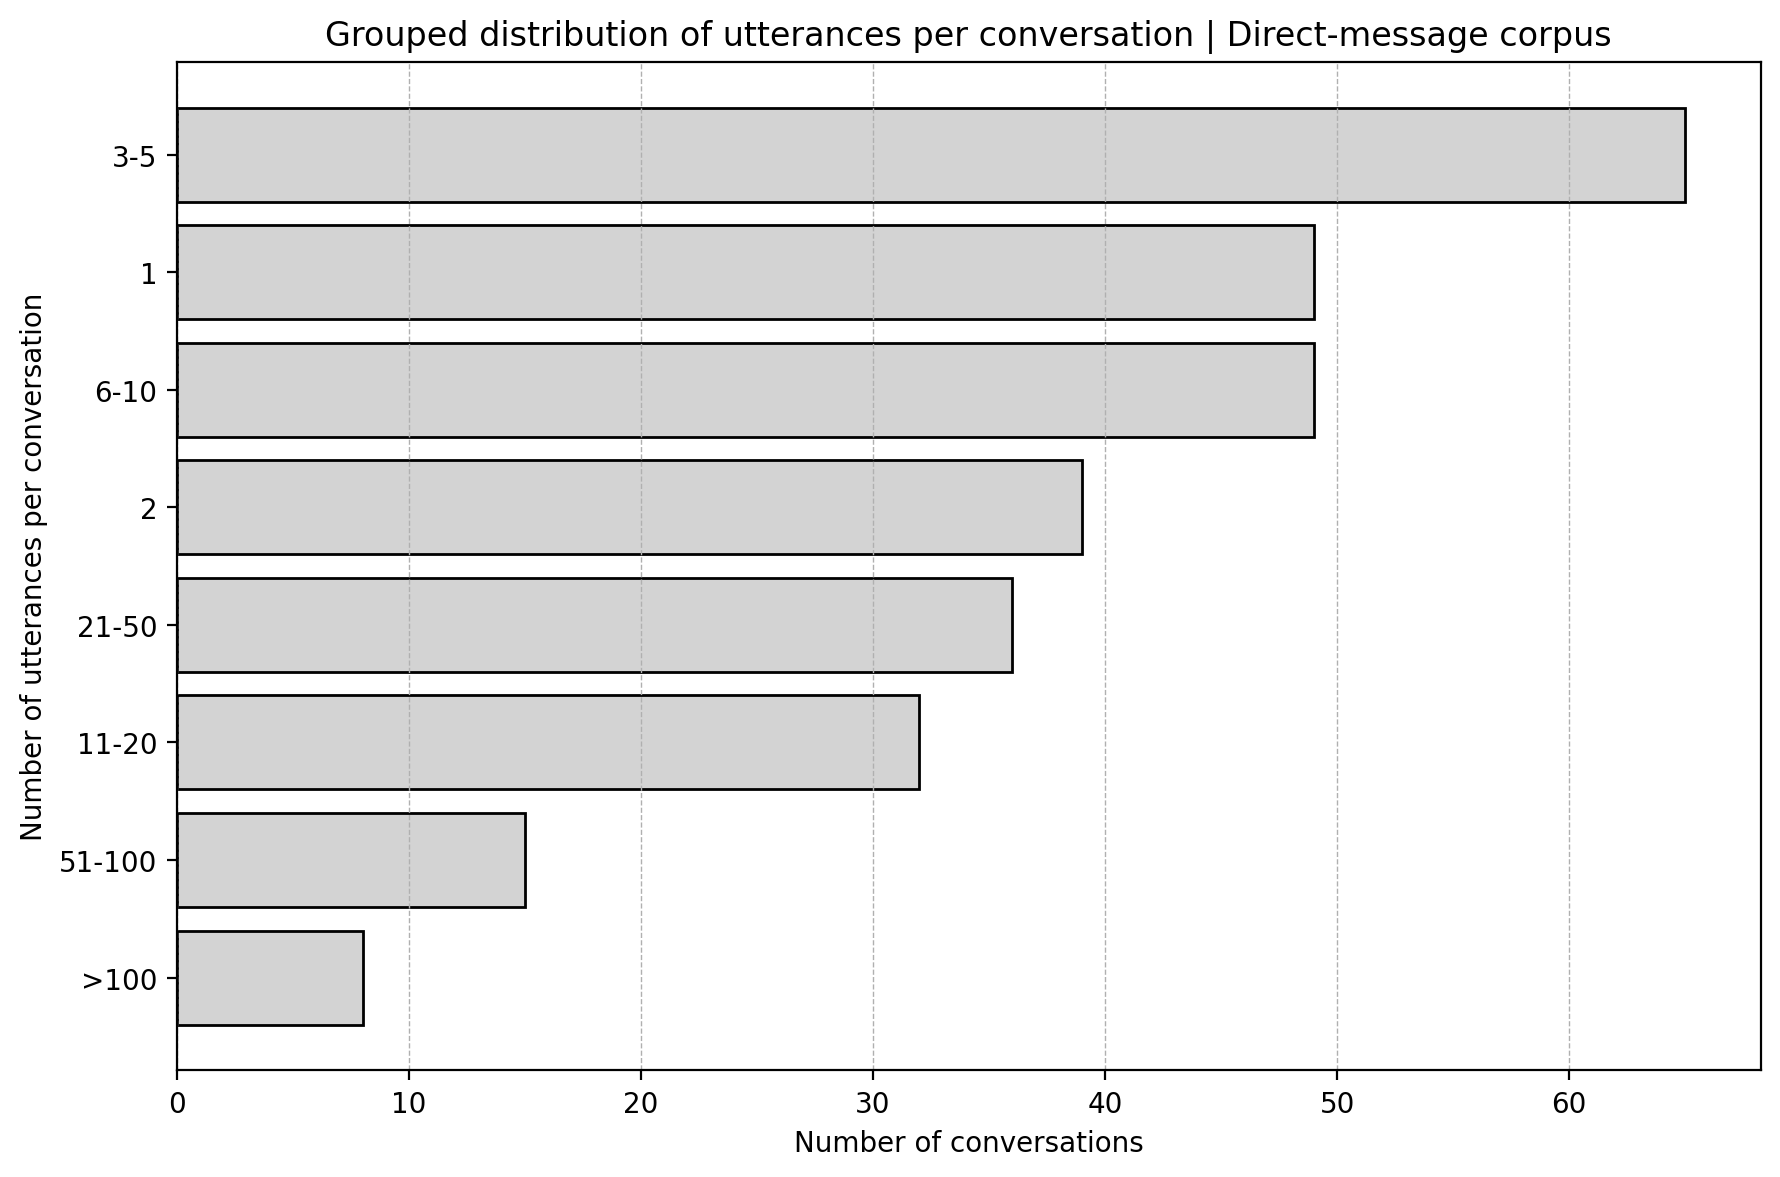

Saved figure to:
/Users/sayegh-jodehl/Documents/Publikationen/Korpusanalyse_JMIR/Code_KorpusAnalyse/output/results/figures/D_grouped_utterances_per_conversation_distribution_horizontal.png


In [126]:
import matplotlib.pyplot as plt

# Sort groups by number of conversations in descending order
plot_df = D_utterance_grouped_df.sort_values(
    by="number_of_conversations",
    ascending=False
)

# Create horizontal bar plot
fig, ax = plt.subplots(figsize=(9, 6))

ax.barh(
    plot_df["utterance_count_group"],
    plot_df["number_of_conversations"],
    color="lightgray",
    edgecolor="black"
)

# Put the largest group at the top
ax.invert_yaxis()

ax.set_title("Grouped distribution of utterances per conversation | Direct-message corpus")
ax.set_xlabel("Number of conversations")
ax.set_ylabel("Number of utterances per conversation")

ax.grid(True, axis="x", linestyle="--", linewidth=0.5)

plt.tight_layout()

# Save figure
plt.savefig(
    FIGURE_OUTPUT_DIR / "D_grouped_utterances_per_conversation_distribution_horizontal.png",
    dpi=300,
    bbox_inches="tight"
)

plt.savefig(
    FIGURE_OUTPUT_DIR / "D_grouped_utterances_per_conversation_distribution_horizontal.svg",
    bbox_inches="tight"
)

plt.show()

print("Saved figure to:")
print(FIGURE_OUTPUT_DIR / "D_grouped_utterances_per_conversation_distribution_horizontal.png")

The grouped distribution of utterances per conversation shows that direct-message communication was dominated by short conversations. Conversations with only one or two utterances formed the largest groups, while longer conversations occurred less frequently.

---

### Number of speakers per conversation <br>
This is not required for the main analysis, since direct-message conversations should usually involve only one to two persons. This step serves only as a validation check.

In [127]:
from convokit import Corpus

# Load the saved ConvoKit corpus from the central corpus output directory
D_corpus = Corpus(filename=CORPUS_OUTPUT_DIR / "D_corpus")

# Initialize a list to store speaker counts per conversation
data = []

# Iterate over all conversations in the corpus
for conversation in D_corpus.iter_conversations():

    conversation_id = conversation.id
    speaker_ids = set()

    # Collect all speaker IDs within the conversation
    for utterance_id in conversation.get_utterance_ids():
        utterance = D_corpus.get_utterance(utterance_id)
        speaker_ids.add(utterance.speaker.id)

    # Add results to list
    data.append({
        "conversation_id": conversation_id,
        "number_of_speakers": len(speaker_ids),
        "speaker_ids": ", ".join(sorted(speaker_ids))
    })

# Create DataFrame with number of speakers per conversation
D_speaker_validation_df = pd.DataFrame(data)

# Display table
display(D_speaker_validation_df)

# Display distribution of speaker counts
speaker_count_distribution = (
    D_speaker_validation_df["number_of_speakers"]
    .value_counts()
    .sort_index()
)

print("Distribution of number of speakers per conversation:")
print(speaker_count_distribution)

# Check for conversations with more than two speakers
unexpected_speaker_counts = D_speaker_validation_df[
    D_speaker_validation_df["number_of_speakers"] > 2
]

if len(unexpected_speaker_counts) > 0:
    print("\nWarning: Some direct-message conversations include more than two speakers.")
    display(unexpected_speaker_counts)
else:
    print("\nValidation passed: all direct-message conversations include one or two speakers.")

# Save validation table
D_speaker_validation_df.to_excel(
    RESULT_TABLE_DIR / "D_speaker_count_validation.xlsx",
    index=False,
    engine="openpyxl"
)

print("Saved validation table to:")
print(RESULT_TABLE_DIR / "D_speaker_count_validation.xlsx")

,conversation_id,number_of_speakers,speaker_ids
0,D_oMD_ano_dq64b8dm7j8zfjrqxj5c7waw1h,2,"Person1, Person2"
1,D_oMD_ckqwfkohjbgx3f91keisjh6tuh,1,Person1
2,D_oMD_w7135snps3d9xdmqz7ktgapw5o,2,"Person1, Person2"
3,D_oMD_ano_xtf5teqg9i8rtcrt6huuwrhu8w,2,"Person1, Person2"
4,D_oMD_wh79x5q17pbaz89jw3xrhd31ua,2,"Person1, Person2"
...,...,...,...
288,D_mMD_pei6gwagftfeij9egd8wkcajye,2,"Person1, Person2"
289,D_mMD_fi17kbdm3ibf7x1teyo6sjdwur,1,Person1
290,D_oMD_ano_cea6fr3i13bppnq3hoj8kezwch,1,Person1
291,D_mMD_7ygxcq5thibbzbsafxk4z8ckqh,2,"Person1, Person2"


Distribution of number of speakers per conversation:
number_of_speakers
1     81
2    212
Name: count, dtype: int64

Validation passed: all direct-message conversations include one or two speakers.
Saved validation table to:
/Users/sayegh-jodehl/Documents/Publikationen/Korpusanalyse_JMIR/Code_KorpusAnalyse/output/results/tables/D_speaker_count_validation.xlsx


In [128]:
from convokit import Corpus

# Load the saved ConvoKit corpus from the central corpus output directory
D_corpus = Corpus(filename=CORPUS_OUTPUT_DIR / "D_corpus")

# Initialize lists to store speaker counts and conversation IDs
num_speakers_list = []
conversation_ids = []

# Iterate over all conversations in the corpus
for conversation in D_corpus.iter_conversations():

    speaker_ids = set()

    # Collect speaker IDs from all utterances in the conversation
    for utterance_id in conversation.get_utterance_ids():
        utterance = D_corpus.get_utterance(utterance_id)
        speaker_ids.add(utterance.speaker.id)

    num_speakers = len(speaker_ids)

    print(
        "Conversation ID:", conversation.id,
        "- Number of speakers:", num_speakers
    )

    num_speakers_list.append(num_speakers)
    conversation_ids.append(conversation.id)

Conversation ID: D_oMD_ano_dq64b8dm7j8zfjrqxj5c7waw1h - Number of speakers: 2
Conversation ID: D_oMD_ckqwfkohjbgx3f91keisjh6tuh - Number of speakers: 1
Conversation ID: D_oMD_w7135snps3d9xdmqz7ktgapw5o - Number of speakers: 2
Conversation ID: D_oMD_ano_xtf5teqg9i8rtcrt6huuwrhu8w - Number of speakers: 2
Conversation ID: D_oMD_wh79x5q17pbaz89jw3xrhd31ua - Number of speakers: 2
Conversation ID: D_oMD_kheihukp57bzbyyzkhwa95n5iw - Number of speakers: 1
Conversation ID: D_oMD_6m9xoczsebdx8ks7o897cqgusr - Number of speakers: 2
Conversation ID: D_oMD_o4arupbmxpy4jyqiorffyrak7r - Number of speakers: 2
Conversation ID: D_oMD_ano_1s4kyirj1t8u7n66b4abg8jo7y - Number of speakers: 1
Conversation ID: D_oMD_cbih9n17bibo7g7jd1sa736a8o - Number of speakers: 2
Conversation ID: D_mMD_onk9o47dhprzubq3gzz5cb8hwy - Number of speakers: 2
Conversation ID: D_oMD_u5y6sm4i4jrnfxwb53iuzr7qqr - Number of speakers: 2
Conversation ID: D_mMD_mk6d6xq1d7g4ixj9zkabz8upyr - Number of speakers: 2
Conversation ID: D_oMD_ano

In [129]:
from convokit import Corpus

# Load the saved ConvoKit corpus from the central corpus output directory
D_corpus = Corpus(filename=CORPUS_OUTPUT_DIR / "D_corpus")

# Lists for conversation-level and utterance-level results
one_speaker_conversation_rows = []
one_speaker_text_rows = []

# Iterate over all conversations in the corpus
for conversation in D_corpus.iter_conversations():

    conversation_id = conversation.id
    utterance_ids = conversation.get_utterance_ids()

    speaker_ids = set()
    utterance_data = []

    # Collect speaker IDs and utterance data for the current conversation
    for utterance_id in utterance_ids:
        utterance = D_corpus.get_utterance(utterance_id)
        speaker_ids.add(utterance.speaker.id)

        utterance_data.append({
            "utterance_id": utterance.id,
            "speaker": utterance.speaker.id,
            "timestamp": utterance.timestamp,
            "text": utterance.text,
            "Channel Name": utterance.meta.get("Channel Name"),
            "Channel Type": utterance.meta.get("Channel Type"),
            "Team Name": utterance.meta.get("Team Name")
        })

    # Keep only conversations with exactly one speaker
    if len(speaker_ids) == 1:

        speaker_id = list(speaker_ids)[0]

        # Sort utterances by timestamp
        utterance_data = sorted(
            utterance_data,
            key=lambda x: x["timestamp"]
        )

        # Combine all utterance texts into one column
        combined_text = "\n\n---\n\n".join(
            item["text"] for item in utterance_data
        )

        # Combine utterance IDs for traceability
        combined_utterance_ids = "; ".join(
            item["utterance_id"] for item in utterance_data
        )

        # Store conversation-level information with appended text column
        one_speaker_conversation_rows.append({
            "conversation_id": conversation_id,
            "number_of_speakers": len(speaker_ids),
            "speaker_id": speaker_id,
            "number_of_utterances": len(utterance_ids),
            "utterance_ids": combined_utterance_ids,
            "combined_utterance_texts": combined_text
        })

        # Store utterance-level information as additional detailed sheet
        for item in utterance_data:
            one_speaker_text_rows.append({
                "conversation_id": conversation_id,
                "utterance_id": item["utterance_id"],
                "speaker": item["speaker"],
                "timestamp": item["timestamp"],
                "text": item["text"],
                "Channel Name": item["Channel Name"],
                "Channel Type": item["Channel Type"],
                "Team Name": item["Team Name"]
            })

# Create DataFrames
D_one_speaker_conversations_df = pd.DataFrame(one_speaker_conversation_rows)
D_one_speaker_texts_df = pd.DataFrame(one_speaker_text_rows)

# Display results
print("Number of one-speaker conversations:", len(D_one_speaker_conversations_df))
print("Number of utterances in one-speaker conversations:", len(D_one_speaker_texts_df))

display(D_one_speaker_conversations_df)

# Save results to Excel
output_file = RESULT_TABLE_DIR / "D_one_speaker_conversations_texts.xlsx"

with pd.ExcelWriter(output_file, engine="openpyxl") as writer:

    # Sheet 1: conversation overview with appended combined utterance texts
    D_one_speaker_conversations_df.to_excel(
        writer,
        sheet_name="conversations_with_texts",
        index=False
    )

    # Sheet 2: utterance-level long format
    D_one_speaker_texts_df.to_excel(
        writer,
        sheet_name="utterances_long_format",
        index=False
    )

print("Saved one-speaker conversation texts to:")
print(output_file)

Number of one-speaker conversations: 81
Number of utterances in one-speaker conversations: 239


,conversation_id,number_of_speakers,speaker_id,number_of_utterances,utterance_ids,combined_utterance_texts
0,D_oMD_ckqwfkohjbgx3f91keisjh6tuh,1,Person1,1,2,"Liebe <Vorname>, wenn Arztbriefe fertig sind a..."
1,D_oMD_kheihukp57bzbyyzkhwa95n5iw,1,Person1,1,11,"Moin! Es hat sich jetzt kurzfristig ergeben, d..."
2,D_oMD_ano_1s4kyirj1t8u7n66b4abg8jo7y,1,Person1,1,27,"Lieber Herr <Nachname>, hier mal zum Test"
3,D_oMD_ano_6wq673qc9jdixpxs35e4dogxhy,1,Person1,1,264,"Liebe Kolleg:innen, könntet ihr mich zum Psych..."
4,D_oMD_ano_agaooigawfnnbp3ysgge9kemth,1,Person1,3,285; 283; 284,"Lieber <Vorname>, kannst Du bitte den folgende..."
...,...,...,...,...,...,...
76,D_mMD_8cq6azqwfpybijk374f411zo9r,1,Person1,7,4836; 4837; 4838; 4839; 4840; 4841; 4842,"Liebe <Vorname>,\n\n---\n\nzur Übergabe vom VD..."
77,D_oMD_bnhpt5bf6pny5pok78sdq6xq4h,1,Person1,1,4843,<Passwort>
78,D_mMD_fi17kbdm3ibf7x1teyo6sjdwur,1,Person1,2,4867; 4868,"liebe <Vorname>, Fr. <Nachname> hat selbst ihr..."
79,D_oMD_ano_cea6fr3i13bppnq3hoj8kezwch,1,Person1,1,4869,https://www.ueberleben.org/


Saved one-speaker conversation texts to:
/Users/sayegh-jodehl/Documents/Publikationen/Korpusanalyse_JMIR/Code_KorpusAnalyse/output/results/tables/D_one_speaker_conversations_texts.xlsx


/var/folders/7w/h2mhddw95r5_yz5g6jrf7s1w0000gn/T/ipykernel_1584/702150251.py:94: UserWarning: Cell contents too long (35882), truncated to 32767 characters
  D_one_speaker_conversations_df.to_excel(


Validation showed that conversations with only one speaker do not represent empty or invalid text entries. Instead, these cases correspond to direct messages that did not receive a reply within the exported chat data.

---

## Determination of the average word count per utterance

In [131]:
import spacy
from convokit import Corpus

# Load the saved ConvoKit corpus from the central corpus output directory
D_corpus = Corpus(filename=CORPUS_OUTPUT_DIR / "D_corpus")

# Load the German spaCy model
nlp = spacy.load("de_core_news_sm")


def assign_utterance_count_group(num_utterances):
    # Assign conversations to utterance-count groups
    if num_utterances == 1:
        return "1"
    elif num_utterances == 2:
        return "2"
    elif num_utterances <= 5:
        return "3-5"
    elif num_utterances <= 10:
        return "6-10"
    elif num_utterances <= 20:
        return "11-20"
    elif num_utterances <= 50:
        return "21-50"
    elif num_utterances <= 100:
        return "51-100"
    else:
        return ">100"


def analyze_utterance_stats(corpus):
    # Define group order
    group_order = [
        "1",
        "2",
        "3-5",
        "6-10",
        "11-20",
        "21-50",
        "51-100",
        ">100"
    ]

    # Define result containers
    word_count_categories = {group: [] for group in group_order}
    sentence_count_categories = {group: [] for group in group_order}
    words_per_sentence_categories = {group: [] for group in group_order}
    conversation_count_categories = {group: 0 for group in group_order}

    # Iterate over all conversations in the corpus
    for conversation in corpus.iter_conversations():

        utterance_ids = conversation.get_utterance_ids()
        num_utterances = len(utterance_ids)

        utterance_count_group = assign_utterance_count_group(num_utterances)

        # Count one conversation in the corresponding group
        conversation_count_categories[utterance_count_group] += 1

        # Iterate over all utterances in the conversation
        for utterance_id in utterance_ids:

            utterance = corpus.get_utterance(utterance_id)
            text = utterance.text if utterance.text is not None else ""

            doc = nlp(text)

            # Count words excluding punctuation and whitespace
            word_count = sum(
                1 for token in doc
                if not token.is_punct and not token.is_space
            )

            # Count sentences
            sentence_count = len(list(doc.sents))

            # Avoid division by zero
            words_per_sentence = (
                word_count / sentence_count
                if sentence_count > 0
                else 0
            )

            word_count_categories[utterance_count_group].append(word_count)
            sentence_count_categories[utterance_count_group].append(sentence_count)
            words_per_sentence_categories[utterance_count_group].append(words_per_sentence)

    # Create result table
    result_rows = []

    for group in group_order:

        average_words = (
            sum(word_count_categories[group]) / len(word_count_categories[group])
            if word_count_categories[group]
            else 0
        )

        average_sentences = (
            sum(sentence_count_categories[group]) / len(sentence_count_categories[group])
            if sentence_count_categories[group]
            else 0
        )

        average_words_per_sentence = (
            sum(words_per_sentence_categories[group])
            / len(words_per_sentence_categories[group])
            if words_per_sentence_categories[group]
            else 0
        )

        result_rows.append({
            "utterance_count_group": group,
            "number_of_conversations_in_group": conversation_count_categories[group],
            "number_of_utterances_in_group": len(word_count_categories[group]),
            "average_words_per_utterance": round(average_words, 2),
            "average_sentences_per_utterance": round(average_sentences, 2),
            "average_words_per_sentence": round(average_words_per_sentence, 2)
        })

    result_df = pd.DataFrame(result_rows)

    return result_df


# Run analysis
D_utterance_stats_by_conversation_length_df = analyze_utterance_stats(D_corpus)

# Display result table
display(D_utterance_stats_by_conversation_length_df)

# Save result table
D_utterance_stats_by_conversation_length_df.to_excel(
    RESULT_TABLE_DIR / "D_utterance_stats_by_conversation_length.xlsx",
    index=False,
    engine="openpyxl"
)

print("Saved utterance statistics table to:")
print(RESULT_TABLE_DIR / "D_utterance_stats_by_conversation_length.xlsx")

,utterance_count_group,number_of_conversations_in_group,number_of_utterances_in_group,average_words_per_utterance,average_sentences_per_utterance,average_words_per_sentence
0,1,49,49,30.82,3.96,7.06
1,2,39,78,18.69,2.19,7.95
2,3-5,65,249,24.94,3.18,7.62
3,6-10,49,367,23.03,2.72,8.48
4,11-20,32,468,20.76,2.43,8.49
5,21-50,36,1192,23.09,2.74,8.36
6,51-100,15,1037,21.67,2.31,9.34
7,>100,8,1475,13.53,1.76,7.29


Saved utterance statistics table to:
/Users/sayegh-jodehl/Documents/Publikationen/Korpusanalyse_JMIR/Code_KorpusAnalyse/output/results/tables/D_utterance_stats_by_conversation_length.xlsx


Across conversation-length groups, utterances in direct-message conversations contained on average between 13.53 and 30.82 words. One-utterance conversations showed the highest average utterance length, suggesting that these cases often consisted of self-contained messages that did not receive a reply. In contrast, very long conversations with more than 100 utterances showed the lowest average word count per utterance, indicating a more interactive communication pattern with shorter conversational turns.

---

## Zeitliche Analyse

In [ ]:
import convokit
from convokit import Corpus, download
import pandas as pd

# Laden des ConvoKit Corpus
corpus_path = cwd
corpus = Corpus(filename=corpus_path)

# Extraktion der Zeitstempel aus den Nachrichten und Umwandlung in eine Pandas DataFrame
timestamps = []
for convo in corpus.iter_conversations():
    for msg in convo.iter_utterances():
        timestamps.append(msg.timestamp)

df = pd.DataFrame(timestamps, columns=['timestamp'])

# Umwandlung des Zeitstempels in lesbares Format
# unit='s' für Unix Zeitstempel in Sekunden
df['timestamp'] = pd.to_datetime(df['timestamp'], unit='s')

# Extraktion von Wochentag und Uhrzeit
df['weekday'] = df['timestamp'].dt.weekday
df['hour'] = df['timestamp'].dt.hour

# Gruppierung und Zählung der Nachrichten nach Wochentag und Stunde
weekday_hour_count = df.groupby(
    ['weekday', 'hour']).size().reset_index(name='count')

# Sortieren der Daten nach Häufigkeit
sorted_data = weekday_hour_count.sort_values(by='count', ascending=False)

print(sorted_data)

### Häufigkeiten der Nachrichten über die Stunden des Tages

In [ ]:
import numpy as np
import convokit
from convokit import Corpus, download
import pandas as pd
import matplotlib.pyplot as plt

# Laden des ConvoKit Corpus
# Bitte stellen Sie sicher, dass 'arbeitsverzeichnisG' korrekt definiert ist.
corpus_path = cwd
corpus = Corpus(filename=corpus_path)

# Extraktion der Zeitstempel aus den Nachrichten und Umwandlung in eine Pandas DataFrame
timestamps = []
for convo in corpus.iter_conversations():
    for msg in convo.iter_utterances():
        timestamps.append(msg.timestamp)

df = pd.DataFrame(timestamps, columns=['timestamp'])

# Umwandlung des Zeitstempels in lesbares Format
df['timestamp'] = pd.to_datetime(df['timestamp'], unit='s')

# Extraktion der Stunde
df['hour'] = df['timestamp'].dt.hour

# Gruppierung und Zählung der Nachrichten nach Stunde
hour_count = df.groupby('hour').size().reset_index(name='count')

# Berechnung der relativen Häufigkeiten
total_messages = hour_count['count'].sum()
hour_count['relative_frequency'] = (
    hour_count['count'] / total_messages) * 100  # in Prozent

# Visualisierung der Daten als horizontales Balkendiagramm
plt.figure(figsize=(14, 8))
# Pastellfarbene Anpassung der Balkenfarbe
pastel_salmon = (1.0, 0.8, 0.7)  # Werte für eine pastellere Lachsfarbe
bars = plt.barh(hour_count['hour'], hour_count['count'], color=pastel_salmon)

# Hinzufügen der Datenwertbeschriftungen zu jedem Balken
for bar in bars:
    xval = bar.get_width()
    rel_freq = hour_count.loc[hour_count['hour'] == bar.get_y(
    ) + bar.get_height()/2, 'relative_frequency'].values[0]
    # Begrenzung der x-Koordinate des Textes, um innerhalb der Grenzen der Grafik zu bleiben
    max_x = max(hour_count['count']) * 1.05  # 5% größer als der größte Balken
    if xval > max_x:
        plt.text(max_x, bar.get_y() + bar.get_height()/2,
                 f'{int(xval)} ({rel_freq:.2f}%)', va='center', fontsize=8, ha='left')
    else:
        plt.text(xval, bar.get_y() + bar.get_height()/2,
                 f'{int(xval)} ({rel_freq:.2f}%)', va='center', fontsize=8, ha='left')

plt.title('Nachrichtenhäufigkeit (Direktnachrichten) nach Stunde des Tages')
plt.ylabel('Stunde des Tages')
plt.xlabel('Anzahl der Nachrichten')

# Anpassung der Y-Achsen-Labels auf das gewünschte Zeitformat
hour_labels = [f"{hour} - {hour+1} Uhr" for hour in range(24)]
plt.yticks(range(24), hour_labels, fontsize=8)
plt.grid(axis='x', linestyle='--', alpha=0.7)

# Y-Achse umdrehen
plt.gca().invert_yaxis()

# Setzen der Grenzen der X-Achse auf 800 Nachrichten
plt.xlim(0, 800)

# Speichert das Bild in hoher Auflösung
plt.savefig("Abb/Dir_HäuStd.png", dpi=300)

plt.show()

### Auswertung über die Wochentage

In [ ]:
import numpy as np
import convokit
from convokit import Corpus, download
import pandas as pd

# Laden des ConvoKit Corpus
# Bitte stellen Sie sicher, dass 'arbeitsverzeichnisG' korrekt definiert ist.
corpus_path = cwd
corpus = Corpus(filename=corpus_path)

# Extraktion der Zeitstempel aus den Nachrichten und Umwandlung in eine Pandas DataFrame
timestamps = []
for convo in corpus.iter_conversations():
    for msg in convo.iter_utterances():
        timestamps.append(msg.timestamp)

df = pd.DataFrame(timestamps, columns=['timestamp'])

# Umwandlung des Zeitstempels in lesbares Format
# unit='s' für Unix Zeitstempel in Sekunden
df['timestamp'] = pd.to_datetime(df['timestamp'], unit='s')

# Extraktion des Wochentags
df['weekday'] = df['timestamp'].dt.dayofweek  # Montag=0, Sonntag=6

# Gruppierung und Zählung der Nachrichten nach Wochentag
weekday_count = df.groupby('weekday').size().reset_index(name='count')

# Prüfung auf Daten in allen Wochentagen
if weekday_count['weekday'].nunique() != 7:
    missing_days = set(range(7)) - set(weekday_count['weekday'])
    for day in missing_days:
        # Füge fehlende Tage mit 0 Nachrichten hinzu
        weekday_count = weekday_count.append(
            {'weekday': day, 'count': 0}, ignore_index=True)

# Sortieren des DataFrames nach Wochentagen
weekday_count = weekday_count.sort_values('weekday')

# Zuordnung der Wochentage zu den Nummern
weekday_labels = ['Montag', 'Dienstag', 'Mittwoch',
                  'Donnerstag', 'Freitag', 'Samstag', 'Sonntag']
weekday_count['weekday'] = weekday_count['weekday'].map(
    lambda x: weekday_labels[x])

# Ausgabe des fertigen DataFrames
print(weekday_count)

Visualisierung Anzahl der NAchrichten pro Wochentag

In [ ]:
import matplotlib.pyplot as plt

# Angenommen, 'weekday_count' ist der DataFrame, der bereits die Nachrichtenzahlen pro Wochentag enthält
weekday_labels = ['Montag', 'Dienstag', 'Mittwoch',
                  'Donnerstag', 'Freitag', 'Samstag', 'Sonntag']

pastel_salmon = (1.0, 0.8, 0.7)  # Werte für eine pastellere Lachsfarbe


# Visualisierung der Daten
plt.figure(figsize=(10, 6))
bars = plt.bar(weekday_count['weekday'],
               weekday_count['count'], color=pastel_salmon)

plt.xlabel('Wochentag')
plt.ylabel('Anzahl der Nachrichten')
plt.title('Anzahl der Nachrichten pro Wochentag (Direktnachrichten)')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7
         )

# Berechnung der Gesamtanzahl der Nachrichten zur Bestimmung der relativen Häufigkeiten
total_messages = weekday_count['count'].sum()

# Bestimmen der maximalen Höhe eines Balkens, um die y-Achsen-Grenzen festzulegen
max_height = max(weekday_count['count'])
# Erweitern des y-Achsen-Limits um 15%
plt.ylim(0, max_height + 0.15 * max_height)

# Hinzufügen der Datenwerte und relativen Häufigkeiten über die Balken
for bar in bars:
    yval = bar.get_height()  # Höhe des Balkens (Anzahl der Nachrichten)
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.001 * total_messages,
             f'{yval}\n({yval/total_messages:.2%})', ha='center', va='bottom')

plt.tight_layout()  # Optimiert den Layout der Darstellung

# Speichert das Bild in hoher Auflösung
plt.savefig("Abb/Dir_NachTagesp.png", dpi=300)


plt.show()

### Ausgabe des kompletten Nachrichtentextes in Rohform und schreiben in die Datei: *D_corpus.txt*

In [ ]:
# Iterieren  über alle Utterance-Objekte im Corpus und Texte ausgeben
for utt in D_corpus.iter_utterances():
    print(utt.text)

In [45]:
# Ergebnis in  Datei schreiben
# Öffnen der Datei im Schreibmodus
with open("D_corpus_roh.txt", "w", encoding="utf-8") as file:
    # Iterieren über alle Utterance-Objekte im Corpus und schreiben der Text in die Datei
    for utt in D_corpus.iter_utterances():
        file.write(utt.text + "\n")

## Emojies

In [ ]:
from convokit import Corpus, download
import re
from collections import Counter
import matplotlib.pyplot as plt

corpus_path = cwd

# Laden des Corpus aus der Datei
corpus = Corpus(filename=corpus_path)

# Regex zum Finden der Emoji-Patterns
emoji_pattern = re.compile(r":\w+:")

# Funktion, um Emojis aus Text zu extrahieren


def extract_emojis(text):
    return emoji_pattern.findall(text)


# Extraktion der Emojis aus jeder Äußerung im Corpus
all_emojis = []
for utterance in corpus.iter_utterances():
    utterance_emojis = extract_emojis(utterance.text)
    all_emojis.extend(utterance_emojis)

# Zählen der Häufigkeiten der Emojis
emoji_counts = Counter(all_emojis)

# Anzeigen der am häufigsten vorkommenden Emojis
print(emoji_counts.most_common(200))

In [ ]:
import pandas as pd
import emoji
from collections import Counter
import re
from convokit import Corpus

corpus_path = cwd

# Laden des Corpus aus der Datei
corpus = Corpus(filename=corpus_path)

# Regex zum Finden der Emoji-Patterns
emoji_pattern = re.compile(r":\w+:")

# Funktion, um Emojis aus Text zu extrahieren


def extract_emojis(text):
    return emoji_pattern.findall(text)


# Extraktion der Emojis aus jeder Äußerung im Corpus und Berechnung der Frequenz pro Äußerung
all_emojis = []
utterance_frequencies = []

for utterance in corpus.iter_utterances():
    # Emojis extrahieren und zählen
    utterance_emojis = extract_emojis(utterance.text)
    all_emojis.extend(utterance_emojis)

    # Emoji-Frequenz pro Äußerung berechnen
    word_count = len(utterance.text.split())
    emoji_count = len(utterance_emojis)
    emoji_frequency = emoji_count / word_count if word_count > 0 else 0
    utterance_frequencies.append({
        'utterance_id': utterance.id,
        'emoji_count': emoji_count,
        'word_count': word_count,
        'emoji_frequency': emoji_frequency
    })

# Erstellen eines DataFrames für die Frequenz pro Äußerung
df_utterance_freq = pd.DataFrame(utterance_frequencies)

# Zählen der Häufigkeiten der Emojis im gesamten Korpus
emoji_counts = Counter(all_emojis)

# Umwandeln der Emoji-Codes in Unicode Emojis (mit dem neuen Parameter)
emoji_unicode = [emoji.emojize(e, language='alias')
                 for e in emoji_counts.keys()]

# Erstellen eines DataFrames mit Unicode, Symbol und deren Häufigkeit
df_emoji_counts = pd.DataFrame({
    'Unicode': list(emoji_counts.keys()),  # Emoji Codes (z.B. :joy:)
    'Symbol': emoji_unicode,               # Entsprechende Unicode-Emojis
    'Häufigkeit': list(emoji_counts.values())  # Häufigkeiten der Emojis
})

# Sortieren des Emoji-DataFrames nach der Häufigkeit
df_emoji_counts_sorted = df_emoji_counts.sort_values(
    by='Häufigkeit', ascending=False)

# Berechnung der durchschnittlichen Emoji-Frequenz im gesamten Korpus
total_word_count = sum(df_utterance_freq['word_count'])
total_emoji_count = sum(df_utterance_freq['emoji_count'])
average_emoji_frequency = total_emoji_count / \
    total_word_count if total_word_count > 0 else 0

# Anzeigen der Ergebnisse
print("Emoji-Häufigkeit pro Äußerung:\n", df_utterance_freq)
print("\nEmoji-Gesamthäufigkeiten im Korpus:\n", df_emoji_counts_sorted)
print(
    f"\nDurchschnittliche Emoji-Frequenz im Korpus: {average_emoji_frequency:.4f}")

In [103]:
df_sorted.to_csv('sorted_emoji_frequencies.csv', index=False, encoding='utf-8')

In [ ]:
import emoji
from IPython.display import HTML

# Definiere ein manuelles Mapping für problematische Emojis


def fix_emoji(emoji_code):
    # Manuelles Mapping für das "relaxed" Emoji
    if emoji_code == ":relaxed:":
        return "😊"  # Alternativer Unicode für ein ähnliches Emoji
    return emoji.emojize(emoji_code, language='alias')


# Filtern des DataFrames für Emojis mit einer Häufigkeit von mindestens 3
df_filtered = df_sorted[df_sorted['Häufigkeit'] >= 3].copy()

# Anwenden der Funktion auf die Spalte "Emoji-Darstellung" und Multiplizieren mit der Häufigkeit
df_filtered['Emoji-Darstellung'] = df_filtered.apply(
    lambda row: fix_emoji(row['Unicode']) * row['Häufigkeit'], axis=1
)

# Erstellen einer neuen Anzeige der Tabelle
df_display = df_filtered[['Häufigkeit', 'Emoji-Darstellung']].rename(columns={
    'Häufigkeit': 'Häufigkeit',
    'Emoji-Darstellung': 'Visuelle Darstellung'
})

# Zeige die Tabelle im HTML-Format (funktioniert in Notebook-Umgebungen wie Jupyter)
display(HTML(f"""
    <div style="display: flex; flex-direction: column; align-items: center; color: black; background-color: white; padding: 20px; border-radius: 10px; box-shadow: 0px 0px 10px rgba(0, 0, 0, 0.1);">
        <h3 style="color: black;">Häufigkeiten von Emojis in Direktnachrichten (mindestens 3 Vorkommen)</h3>
        {df_display.to_html(index=False, escape=False).replace(
    '<td>', '<td style="text-align: left; color: black;">').replace('<th>', '<th style="color: black;">')}
    </div>
"""))

## ________________________________________________________________________________________

# Cleaning corpusspezifisch

## 1. entfernen von "< enter >" Marken

In [109]:
corpus_path = cwd

# Laden des Corpus aus der Datei
corpus = Corpus(filename=corpus_path)

replacements1 = {
    "<enter>": "",
    "< enter>": "",
    "< enter >": "",
    "<enter > ": "",
    "enter>": "",
    " <enter> ": ""}

# Schleife über die Utterances im Corpus und Anwenden der Ersetzungen
for utterance in corpus.iter_utterances():
    updated_text = utterance.text  # Kopie des ursprünglichen Texts
    # Kombinieren Sie alle Ersetzungen in einer Schleife
    for replacements in [replacements1]:
        for pattern, replacement in replacements.items():
            updated_text = updated_text.replace(pattern, replacement)
    utterance.text = updated_text


# Speichern des Corpus
corpus.dump(
    r"C:\Users\sayeghjs\OneDrive - Charité - Universitätsmedizin Berlin\1 DocTalk\ChatCorpus\Codieraufgaben\Analyse_direktNachrichten\D_Corpus_clean_V")

In [110]:

# Laden des ConvoKit Corpus
corpus_path = r"C:\Users\sayeghjs\OneDrive - Charité - Universitätsmedizin Berlin\1 DocTalk\ChatCorpus\Codieraufgaben\Analyse_direktNachrichten\D_Corpus_clean_V"
corpus = Corpus(filename=corpus_path)



replacements1 = {
    "#": "",
    ",": "",
    ":": "",
    ";": "",
    "*": "",
    "(": "",
    ")": "",
    ".": "",
    "-": ""
}

replacements2 = {

    "to do": " Platzhalter ",
    "to do's ": " Platzhalter ",
    "to dos": " Platzhalter ",
    "todos": " Platzhalter ",
    "To Dos": " Platzhalter ",
    "To Do": " Platzhalter ",
    "To do's": " Platzhalter ",
    "To do ' s": " Platzhalter ",
    "to do's": " Platzhalter ",
    "To-Do's": " Platzhalter ",
    "Todo's": " Platzhalter ",
    "To dos": " Platzhalter ",
    " to Dos ": " Platzhalter "
}

replacements3 = {
    "keine aktiven  Platzhalter 's": "kein_Todo",
    "kein  Platzhalter": "kein_Todo",
    "keine aktiven  Platzhalter": "kein_Todo",
    "kein aktives  Platzhalter": "kein_Todo",
    "keine  Platzhalter s": "kein_Todo",
    "aktiven ToDo'skann": "kein_Todo",
    "keine akuten  Platzhalter": "kein_Todo",
    "kein aktives  Platzhalter": "kein_Todo"
}

replacements4 = {
    " Platzhalter": " Todo ",
    " Platzhalter 's ": " Todo "
}

replacements5 = {
    "Frau ": " ",
    "Fr ": " ",
    " Fr ": " ",
    "Hr ": " ",
    "Herr": " ",
    "Herrn": " "
}

replacements6 = {
    "<Nachname>": " Ersatz ",
    "<Nachname> ": " Ersatz ",
    "<Name_Abkürzung>": " Ersatz ",
    "Patient": " Ersatz ",
    "Patient_in": " Ersatz ",
    "Pat.": " Ersatz ",
    "Pat. ": " Ersatz ",
    "Pat": " Ersatz ",
    "Patient_in": " Ersatz ",
    "Herr < Name_Abkürzung >": " Ersatz "
}

replacements7 = {
    " Ersatz ": " PatName ",
    " Gesprächsgruppe ": " GT ",
    " kt ": "KT",
    " mt ": "MT",
}

replacements8 = {
    " > ": " ",
    "> ": " ",
    " >": " ",
    ">": " ",
    "<": " ",
    " < ": " ",
    "< ": " ",
    " <": " ",
    "@": " "
}


# Schleife über die Utterances im Corpus und Anwenden der Ersetzungen

for utterance in corpus.iter_utterances():
    updated_text = utterance.text  # Kopie des ursprünglichen Texts

    # Kombinieren Sie alle Ersetzungen in einer Schleife
    for replacements in [replacements1, replacements2, replacements3, replacements4,
                         replacements5, replacements6, replacements7, replacements8]:
        for pattern, replacement in replacements.items():
            updated_text = updated_text.replace(pattern, replacement)

    utterance.text = updated_text


# Speichern des Corpus
corpus.dump(
    r"C:\Users\sayeghjs\OneDrive - Charité - Universitätsmedizin Berlin\1 DocTalk\ChatCorpus\Codieraufgaben\Analyse_direktNachrichten\D_Corpus_clean")

In [ ]:
# Pfad zur Datei des Corpus
corpus_path = r"C:\Users\sayeghjs\OneDrive - Charité - Universitätsmedizin Berlin\1 DocTalk\ChatCorpus\Codieraufgaben\Analyse_direktNachrichten\D_Corpus_clean"
corpus = Corpus(filename=corpus_path)

# Iterieren  über alle Utterance-Objekte im Corpus und Texte ausgeben
for utt in corpus.iter_utterances():
    print(utt.text)

In [ ]:
from convokit import Corpus  

# Pfad zur Datei des Corpus
corpus_path = r"C:\Users\sayeghjs\OneDrive - Charité - Universitätsmedizin Berlin\1 DocTalk\ChatCorpus\Codieraufgaben\Analyse_direktNachrichten\D_Corpus_clean"
corpus = Corpus(filename=corpus_path)

# Iterieren über alle Utterance-Objekte im Corpus und Texte mit Utterance ID ausgeben
for utt in corpus.iter_utterances():
    print(f"Utterance ID: {utt.id}")
    print(f"Text: {utt.text}\n")

## Sentimentanalyse 

### Analyse mit Roberta Model für Twitter auf Deutsch optimiert "citizenlab/twitter-xlm-roberta-base-sentiment-finetunned"

In [ ]:
from convokit import Corpus
from transformers import AutoTokenizer, AutoModelForSequenceClassification, pipeline
import pandas as pd
import matplotlib.pyplot as plt

# Laden des Transformers-Modells
tokenizer = AutoTokenizer.from_pretrained(
    "citizenlab/twitter-xlm-roberta-base-sentiment-finetunned")
model = AutoModelForSequenceClassification.from_pretrained(
    "citizenlab/twitter-xlm-roberta-base-sentiment-finetunned")


def extract_texts_from_corpus(corpus):
    """
    Extrahiert Texte aus einem Convokit Corpus.

    Args:
        corpus (Corpus): Der Convokit Corpus.

    Returns:
        list: Eine Liste mit den Texten aller Utterances im Corpus.
    """
    texts = []
    for utterance in corpus.iter_utterances():
        texts.append(utterance.text)
    return texts


def analyze_sentiment_with_roberta_and_export(texts, output_file="sentiment_analysis.csv"):
    """
    Analysiert Sentiments mit Roberta und exportiert Ergebnisse als CSV.

    Args:
        texts (list): Eine Liste von Texten.
        output_file (str): Der Dateiname für die CSV-Ausgabe.

    Returns:
        dict: Sentiment counts für positive, neutrale und negative Texte.
    """
    # Sentiment-Analyse initialisieren
    sentiment_pipeline = pipeline(
        "sentiment-analysis", model=model, tokenizer=tokenizer)

    # Kategorien und Zähler
    sentiment_counts = {"positive": 0, "neutral": 0, "negative": 0}
    results = []

    for text in texts:
        result = sentiment_pipeline(text[:512])  # Token-Limit beachten
        label = result[0]["label"].lower()
        score = result[0]["score"]

        # Sentiment-Ergebnisse speichern
        results.append({
            "Text": text,
            "Sentiment": label,
            "Score": score
        })

        # Sentiment-Zähler aktualisieren
        if label in sentiment_counts:
            sentiment_counts[label] += 1

    # Ergebnisse in CSV exportieren
    df = pd.DataFrame(results)
    # Kodierung hier angegeben
    df.to_csv(output_file, index=False, encoding="utf-8")
    print(f"Sentiment analysis results exported to {output_file}")

    return sentiment_counts


def visualize_sentiment(sentiment_counts):
    """
    Visualisiert die Sentiment-Verteilung mit einem Balkendiagramm.

    Args:
        sentiment_counts (dict): Sentiment counts für positive, neutrale und negative Texte.
    """
    categories = list(sentiment_counts.keys())
    counts = list(sentiment_counts.values())

    # Balkendiagramm erstellen
    plt.figure(figsize=(8, 5))
    plt.bar(categories, counts, color=["green", "grey", "red"])
    plt.title("Sentiment Distribution (Roberta)")
    plt.xlabel("Sentiment")
    plt.ylabel("Count")
    plt.grid(axis="y", linestyle="--", alpha=0.7)

    # Diagramm abspeichern

    plt.show()

# Statistik berechnen
    total_texts = len(texts)
    statistics = []
    for sentiment, count in sentiment_counts.items():
        relative_frequency = (count / total_texts) * \
            100 if total_texts > 0 else 0
        statistics.append({
            "Sentiment": sentiment,
            "Absolute Frequency": count,
            "Relative Frequency (%)": relative_frequency
        })

    stats_df = pd.DataFrame(statistics)
    print("\nSentiment Statistics:\n", stats_df)

    return sentiment_counts, stats_df


# Pfad zur Datei des Corpus
corpus_path = r"C:\Users\sayeghjs\OneDrive - Charité - Universitätsmedizin Berlin\1 DocTalk\ChatCorpus\Codieraufgaben\Analyse_direktNachrichten\D_Corpus_clean"
corpus = Corpus(filename=corpus_path)

# Texte aus dem Corpus extrahieren
texts = extract_texts_from_corpus(corpus)

# Sentimentanalyse durchführen und Ergebnisse exportieren
sentiment_counts = analyze_sentiment_with_roberta_and_export(
    texts, output_file="utterances_sentiment.csv"
)

# Ergebnisse visualisieren
visualize_sentiment(sentiment_counts)

### Gemeinsame Darstellung der Gruppen und Direktnachrichten Sentiment

In [ ]:
!pip install seaborn

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Daten für das Diagramm vorbereiten
data = {
    'Sentiment': ['Positiv', 'Neutral', 'Negativ', 'Positiv', 'Neutral', 'Negativ'],
    'Prozent': [13.536413, 83.498084, 2.965503, 8.672087, 89.663182, 1.664731],
    'Kommunikationsform': ['Direktnachrichten', 'Direktnachrichten', 'Direktnachrichten',
                           'Gruppennachrichten', 'Gruppennachrichten', 'Gruppennachrichten']
}

df = pd.DataFrame(data)

# Figure und Größe festlegen
plt.figure(figsize=(12, 6))

# Sentiment-spezifische Farben definieren
colors = {'Positiv': '#2ecc71',    # Grün
          'Neutral': '#95a5a6',    # Grau
          'Negativ': '#e74c3c'}    # Rot

# Zwei separate Balkendiagramme für die verschiedenen Kommunikationsformen erstellen
bar_width = 0.35
index = range(3)  # für die drei Sentiments

# Daten für beide Kommunikationsformen separieren
direkt = df[df['Kommunikationsform'] == 'Direktnachrichten']['Prozent'].values
gruppe = df[df['Kommunikationsform'] == 'Gruppennachrichten']['Prozent'].values

# Balken für Direktnachrichten
plt.bar([i - bar_width/2 for i in index], direkt, bar_width,
        label='Direktnachrichten',
        color=[colors['Positiv'], colors['Neutral'], colors['Negativ']],
        alpha=1)

# Balken für Gruppennachrichten
plt.bar([i + bar_width/2 for i in index], gruppe, bar_width,
        label='Gruppennachrichten',
        color=[colors['Positiv'], colors['Neutral'], colors['Negativ']],
        alpha=0.7)  # leicht transparent für Unterscheidung

# Prozentangaben über den Balken hinzufügen
for i in index:
    # Für Direktnachrichten
    plt.text(i - bar_width/2, direkt[i], f'{direkt[i]:.1f}%',
             ha='center', va='bottom')
    # Für Gruppennachrichten
    plt.text(i + bar_width/2, gruppe[i], f'{gruppe[i]:.1f}%',
             ha='center', va='bottom')

# Diagramm-Eigenschaften anpassen
plt.title('Vergleich der Sentiment-Verteilung in Direkt- und Gruppennachrichten',
          pad=20, fontsize=14)
plt.xlabel('Sentiment', fontsize=12)
plt.ylabel('Anteil in Prozent', fontsize=12)

# X-Achsen-Labels anpassen
plt.xticks(index, ['Positiv', 'Neutral', 'Negativ'])

# Y-Achse von 0 bis 100 skalieren
plt.ylim(0, 100)

# Legende anpassen
plt.legend(title='Kommunikationsform',
           bbox_to_anchor=(1.05, 1), loc='upper left')

# Layout optimieren
plt.tight_layout()

# Plot anzeigen
plt.show()

# Optional: Plot speichern
# plt.savefig('sentiment_comparison.png', dpi=300, bbox_inches='tight')
# plt.close()

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Daten vorbereiten
# Äußerer Ring (Gruppennachrichten)
group_values = [8.672087, 89.663182, 1.664731]  # Positiv, Neutral, Negativ
# Innerer Ring (Direktnachrichten)
direct_values = [13.536413, 83.498084, 2.965503]  # Positiv, Neutral, Negativ

# Farben definieren
colors = ['#2ecc71', '#95a5a6', '#e74c3c']  # Grün, Grau, Rot

# Figur erstellen
plt.figure(figsize=(10, 10))

# Größerer (äußerer) Ring für Gruppennachrichten
plt.pie(group_values,
        radius=1.3,
        colors=colors,
        labels=['Positiv\n(8,7%)', 'Neutral\n(89,7%)', 'Negativ\n(1,7%)'],
        labeldistance=0.85,
        pctdistance=0.7,
        startangle=90,
        counterclock=False)

# Kleinerer (innerer) Ring für Direktnachrichten
plt.pie(direct_values,
        radius=1.0,
        colors=colors,
        labels=['Positiv\n(13,5%)', 'Neutral\n(83,5%)', 'Negativ\n(3,0%)'],
        labeldistance=0.6,
        pctdistance=0.45,
        startangle=90,
        counterclock=False)

# Titel und Legende
plt.title('SENTIMENT\nGruppennachrichten (außen) vs. Direktnachrichten (innen)',
          pad=20, fontsize=14)

# Mitte ausschneiden für Donut-Effekt
centre_circle = plt.Circle((0, 0), 0.70, fc='white')
fig = plt.gcf()
fig.gca().add_artist(centre_circle)

# Layout optimieren
plt.tight_layout()

# Plot anzeigen
plt.show()

# Optional: Plot speichern
# plt.savefig('sentiment_donut_comparison.png', dpi=300, bbox_inches='tight')
# plt.close()

#### Schreibe den Messagetext in eine csv Datei für Bertopic

Der Corpus wird nur um die Wichtigsten Dinge gereinigt und normalisiert, Satzzeichen bleiben erhalten

In [111]:
# Laden des ConvoKit Corpus
corpus_path = r"C:\Users\sayeghjs\OneDrive - Charité - Universitätsmedizin Berlin\1 DocTalk\ChatCorpus\Codieraufgaben\Analyse_direktNachrichten\D_Corpus_clean_V"
corpus = Corpus(filename=corpus_path)


replacements1 = {
    "#": "",
    "*": ""
}


replacements5 = {
    "Frau ": " ",
    "Fr ": " ",
    " Fr ": " ",
    "Hr ": " ",
    "Herr": " ",
    "Herrn": " "
}

replacements6 = {
    "<Nachname>": " Ersatz ",
    "<Nachname> ": " Ersatz ",
    "<Name_Abkürzung>": " Ersatz ",
    "Patient": " Ersatz ",
    "Patient_in": " Ersatz ",
    "Pat.": " Ersatz ",
    "Pat. ": " Ersatz ",
    "Pat": " Ersatz ",
    "Patient_in": " Ersatz ",
    "Herr < Name_Abkürzung >": " Ersatz "
}

replacements7 = {
    " Ersatz ": " PatName ",
    " Gesprächsgruppe ": " GT ",
    " kt ": "KT",
    " mt ": "MT",
}

replacements8 = {
    " > ": " ",
    "> ": " ",
    " >": " ",
    ">": " ",
    "<": " ",
    " < ": " ",
    "< ": " ",
    " <": " ",
    "@": " "
}


# Schleife über die Utterances im Corpus und Anwenden der Ersetzungen

for utterance in corpus.iter_utterances():
    updated_text = utterance.text  # Kopie des ursprünglichen Texts

    # Kombinieren Sie alle Ersetzungen in einer Schleife
    for replacements in [replacements1, replacements2, replacements3, replacements4,
                         replacements5, replacements6, replacements7, replacements8]:
        for pattern, replacement in replacements.items():
            updated_text = updated_text.replace(pattern, replacement)

    utterance.text = updated_text


# Speichern des Corpus
corpus.dump(
    r"C:\Users\sayeghjs\OneDrive - Charité - Universitätsmedizin Berlin\1 DocTalk\ChatCorpus\Codieraufgaben\Analyse_direktNachrichten\D_Corpus_clean_V2")

In [ ]:
import pandas as pd
import convokit 

# Pfad zur Datei des Corpus
corpus_path =  r"C:\Users\sayeghjs\OneDrive - Charité - Universitätsmedizin Berlin\1 DocTalk\ChatCorpus\Codieraufgaben\Analyse_direktNachrichten\D_Corpus_clean_V2"
corpus = Corpus(filename=corpus_path)

# Extrahiere nur die Nachrichtentexte aus dem Corpus
message = [utt.text for utt in corpus.iter_utterances()]

# Erstelle einen DataFrame mit einer Spalte für den Nachrichtentext
df = pd.DataFrame(message, columns=['message_text'])

# Speichere die Nachrichtentexte in einer CSV-Datei
output_path = r"C:\Users\sayeghjs\OneDrive - Charité - Universitätsmedizin Berlin\1 DocTalk\ChatCorpus\Codieraufgaben\Analyse_direktNachrichten\Corpus_clean_texts.csv"
df.to_csv(output_path, index=False)
print("Nachrichtentexte wurden erfolgreich in eine CSV-Datei **Corpus_clean_texts.csv** exportiert.")

Text in Datei des gereinigten Corpus *UG_corpus_cleaned.txt* 

In [66]:
# Pfad zur Datei des Corpus
corpus_path = r"C:\Users\sayeghjs\OneDrive - Charité - Universitätsmedizin Berlin\1 DocTalk\ChatCorpus\Codieraufgaben\Analyse_direktNachrichten\D_Corpus_clean"
corpus = Corpus(filename=corpus_path)

# Ergebnis in eine Datei schreiben
# Öffnen der Datei im Schreibmodus
with open("UG_corpus_cleaned.txt", "w", encoding="utf-8") as file:
    # Iterieren über alle Utterance-Objekte im Corpus und schreiben der Text in die Datei
    for utt in corpus.iter_utterances():
        file.write(utt.text + "\n")

Wortliste erstellen und in Datei speichern

In [67]:
# Pfad zur Datei des Corpus
corpus_path = r"C:\Users\sayeghjs\OneDrive - Charité - Universitätsmedizin Berlin\1 DocTalk\ChatCorpus\Codieraufgaben\Analyse_direktNachrichten\D_Corpus_clean"
corpus = Corpus(filename=corpus_path)

# Wortliste erstellen und in Datei speichern
# Extrahieren der Wortliste aus dem Corpus
word_list = []
for utterance in corpus.iter_utterances():
    tokens = utterance.text.split()
    word_list.extend(tokens)

# Speichern der Wortliste in einer Datei
with open("word_list_voll.txt", "w", encoding="utf-8") as file:
    for word in word_list:
        file.write(word + "\n")

Am häufigsten verwendete Wörter vor Stopwortentfernung:

In [ ]:
from collections import Counter

# Pfad zur Datei des Corpus
corpus_path = r"C:\Users\sayeghjs\OneDrive - Charité - Universitätsmedizin Berlin\1 DocTalk\ChatCorpus\Codieraufgaben\Analyse_direktNachrichten\D_Corpus_clean"
corpus = Corpus(filename=corpus_path)

# Extrahieren und zählen der Wörter aus den Nachrichten
text_data = [utterance.text for utterance in corpus.iter_utterances()]
word_counts = Counter(" ".join(text_data).split())

# Die 100 am häufigsten verwendeten Wörter
most_common_words = word_counts.most_common(100)
print("Die 200 am häufigsten verwendeten Wörter:", most_common_words)

# Speichern der 100 am häufigsten verwendeten Wörter in einer Textdatei
with open("most_common_words.txt", "w", encoding="utf-8") as file:
    for word, count in most_common_words:
        file.write(f"{word}: {count}\n")

print("Die 100 am häufigsten verwendeten Wörter wurden in 'most_common_words.txt' gespeichert.")

Wortzahlen pro Utterance vor Stopwortentfernung

In [ ]:
from convokit import Corpus

# Laden des ConvoKit Corpus
corpus_path = r"C:\Users\sayeghjs\OneDrive - Charité - Universitätsmedizin Berlin\1 DocTalk\ChatCorpus\Codieraufgaben\Analyse_direktNachrichten\D_Corpus_clean"
corpus = Corpus(filename=corpus_path)

# Funktion zur Berechnung der Wortanzahl in einem Text


def count_words(text):
    # Trennen des Texts in Wörter (Worte sind durch Leerzeichen getrennt)
    words = text.split()
    # Rückgabe der Anzahl der Wörter im Text
    return len(words)


# Durchlaufen aller Utterances im Corpus und Berechnen der Wortanzahl
for utterance in corpus.iter_utterances():
    text = utterance.text
    word_count = count_words(text)
    print(f"Utterance ID: {utterance.id}, Wortanzahl: {word_count}")

Gesamtzahl der Wörter im Corpus vor Entfernung der Stopwörter

In [ ]:
# Laden des ConvoKit Corpus
corpus_path = r"C:\Users\sayeghjs\OneDrive - Charité - Universitätsmedizin Berlin\1 DocTalk\ChatCorpus\Codieraufgaben\Analyse_direktNachrichten\D_Corpus_clean"
corpus = Corpus(filename=corpus_path)

# Funktion zur Berechnung der Wortanzahl in einem Text


def count_words(text):
    words = text.split()
    return len(words)


# Initialisieren einer Variablen für die Gesamtzahl der Wörter
total_word_count = 0

# Durchlaufen aller Utterances im Corpus und Berechnen der Wortanzahl
for utterance in corpus.iter_utterances():
    total_word_count += count_words(utterance.text)

print(
    f"Gesamtzahl der Wörter im Corpus vor Entfernung der Stopwörter: {total_word_count}")

Durchschnittliche Anzahl von Wörtern pro Utterance vor Entfernung der Stopwörter

In [ ]:
# Laden des ConvoKit Corpus
corpus_path = r"C:\Users\sayeghjs\OneDrive - Charité - Universitätsmedizin Berlin\1 DocTalk\ChatCorpus\Codieraufgaben\Analyse_direktNachrichten\D_Corpus_clean"
corpus = Corpus(filename=corpus_path)

# Funktion zur Berechnung der Wortanzahl in einem Text


def count_words(text):
    # Trennen des Texts in Wörter (Worte sind durch Leerzeichen getrennt)
    words = text.split()
    # Rückgabe der Anzahl der Wörter im Text
    return len(words)


# Berechnung der durchschnittlichen Wortanzahl
word_count = [count_words(utterance.text)
              for utterance in corpus.iter_utterances()]
durchschnittliche_wortanzahl = sum(word_count) / len(word_count)

# Ausgabe der durchschnittlichen Wortanzahl
print("Direktnachrichten: Durchschnittliche Wortanzahl pro Äußerung vor Entfernung der Stopwörter: " +
      str(round(durchschnittliche_wortanzahl, 2)))

In [ ]:
import numpy as np
from convokit import Corpus

# Laden des Convokit-Corpus
corpus_path = r"C:\Users\sayeghjs\OneDrive - Charité - Universitätsmedizin Berlin\1 DocTalk\ChatCorpus\Codieraufgaben\Analyse_direktNachrichten\D_Corpus_clean"
corpus = Corpus(filename=corpus_path)

# Liste zur Speicherung der Wortzahlen pro Äußerung
word_counts = []

# Durchlaufen aller Äußerungen im Corpus und Zählen der Wortzahlen
for utterance in corpus.iter_utterances():
    words = utterance.text.split()  # Text in Wörter aufteilen
    word_count = len(words)
    word_counts.append(word_count)

# Erstellen von Intervallen (Bins) für die Gruppierung
bins = [0, 10, 20, 30, 40, 50, np.inf]

# Zählen der Wortzahlen in den Intervallen
word_count_groups = np.histogram(word_counts, bins=bins)

# Ausgabe der Anzahl der Wörter in den Intervallen
for i, count in enumerate(word_count_groups[0]):
    if i < len(bins) - 1:
        print(f"{bins[i]}-{bins[i+1]-1} Wörter: {count} Äußerungen")
    else:
        print(f"{bins[i]} und mehr Wörter: {count} Äußerungen")

In [ ]:
import matplotlib.pyplot as plt
from convokit import Corpus

# Laden des Convokit-Corpus
corpus_path = r"C:\Users\sayeghjs\OneDrive - Charité - Universitätsmedizin Berlin\1 DocTalk\ChatCorpus\Codieraufgaben\Analyse_direktNachrichten\D_Corpus_clean"
corpus = Corpus(filename=corpus_path)

# Listen zur Speicherung der Wortzahlen
word_counts = []

# Durchlaufen aller Äußerungen im Corpus
for utterance in corpus.iter_utterances():
    words = utterance.text.split()  # Text in Wörter aufteilen
    word_count = len(words)

    word_counts.append(word_count)
    # additional_feature_values.append(additional_feature)

# Erstellen des Scatterplots
plt.scatter(range(len(word_counts)), word_counts, marker='o', c='#6080c0')
plt.xlabel('Äußerungen')
plt.ylabel('Wortanzahl pro Äußerung vor Entfernung der Stopwörter')
plt.title('Scatterplot der Wortzahlen pro Äußerung')
plt.grid(True)

plt.show()

In [ ]:

import numpy as np
# Laden des Convokit-Corpus
corpus_path = r"C:\Users\sayeghjs\OneDrive - Charité - Universitätsmedizin Berlin\1 DocTalk\ChatCorpus\Codieraufgaben\Analyse_direktNachrichten\D_Corpus_clean"
corpus = Corpus(filename=corpus_path)

# Liste zur Speicherung der Wortzahlen pro Äußerung
word_counts = []

# Durchlaufen aller Äußerungen im Corpus
for utterance in corpus.iter_utterances():
    words = utterance.text.split()  # Text in Wörter aufteilen
    word_count = len(words)
    word_counts.append(word_count)

# Sortieren der Wortzahlen
sorted_word_counts = sorted(word_counts)

# Berechnung der CDF
cdf = np.arange(1, len(sorted_word_counts) + 1) / len(sorted_word_counts)

# Erstellen des CDF-Diagramms
plt.plot(sorted_word_counts, cdf, marker='.', linestyle='none', c='#6080c0')
plt.xlabel('Wortanzahl pro Äußerung vor Entfernung der Stopwörter')
plt.ylabel('Kumulative Wahrscheinlichkeit')
plt.title('Kumulative Verteilung der Wortzahlen pro Äußerung')
plt.grid(True)

plt.show()

Wordcloud erstellen des Corpus vor Bearbeitung

In [ ]:
import matplotlib.pyplot as plt
from wordcloud import WordCloud
from collections import Counter

# Pfad zur Datei des Corpus
corpus_path = r"C:\Users\sayeghjs\OneDrive - Charité - Universitätsmedizin Berlin\1 DocTalk\ChatCorpus\Codieraufgaben\Analyse_direktNachrichten\D_Corpus_clean"
corpus = Corpus(filename=corpus_path)

# Extrahieren und zählen der Wörter aus den Nachrichten
text_data = [utterance.text for utterance in corpus.iter_utterances()]
word_counts = Counter(" ".join(text_data).split())

# Erstellen der Word Cloud
wordcloud = WordCloud(width=800, height=400, margin=5, background_color='white',
                      scale=3).generate_from_frequencies(word_counts)

# Anzeigen der Word Cloud
plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis("off")
plt.title("Word Cloud der häufigsten Wörter vor Entfernung der Stopwörter")
plt.show()

_________________________________________________________________________________________________

### Entfernen von Stoppwörtern
stopwords von nltk verwenden, um deutsche Stoppwörter aus dem Texten zu entfernen

In [ ]:
import nltk
from nltk.corpus import stopwords

# Laden Sie die deutschen Stoppwörter
nltk.download('stopwords')
stop_words = set(stopwords.words('german'))

In [47]:
stop_words = set(stopwords.words('german'))

# Speichern der Stoppwörter in einer Datei
with open("german_stopwords.txt", "w", encoding="utf-8") as file:
    for word in stop_words:
        file.write(word + "\n")

In [48]:
# Pfad zur Datei des Corpus
corpus_path = r"C:\Users\sayeghjs\OneDrive - Charité - Universitätsmedizin Berlin\1 DocTalk\ChatCorpus\Codieraufgaben\Analyse_direktNachrichten\D_Corpus_clean"
corpus = Corpus(filename=corpus_path)

# Funktion um Stoppwörter zu entfernen


def remove_stopwords(text):
    words = text.split()
    filtered_words = [word for word in words if word.lower() not in stop_words]
    return " ".join(filtered_words)


# Schleife über die Utterances im Corpus und Anwenden der Stoppwortentfernung
for utt in corpus.iter_utterances():
    utt.text = remove_stopwords(utt.text)

# Pfad zur neuen Datei für den angepassten Corpus
new_corpus_path = r"C:\Users\sayeghjs\OneDrive - Charité - Universitätsmedizin Berlin\1 DocTalk\ChatCorpus\Codieraufgaben\Analyse_direktNachrichten\D_Corpus_nostop"

# Speichern des angepassten Corpus in der neuen Datei
corpus.dump(new_corpus_path)

In [ ]:
# Pfad zur Datei des Corpus
corpus_path = r"C:\Users\sayeghjs\OneDrive - Charité - Universitätsmedizin Berlin\1 DocTalk\ChatCorpus\Codieraufgaben\Analyse_direktNachrichten\D_Corpus_nostop"
corpus = Corpus(filename=corpus_path)

for utterance in corpus.iter_utterances():
    print(utterance.text)

In [50]:
# Pfad zur Textdatei, in der die Utterance-Texte gespeichert werden
text_file_path = r"C:\Users\sayeghjs\OneDrive - Charité - Universitätsmedizin Berlin\1 DocTalk\ChatCorpus\Codieraufgaben\Analyse_direktNachrichten\D_Corpus_text.txt"

# Öffnen der Textdatei im Schreibmodus
with open(text_file_path, 'w', encoding='utf-8') as text_file:
    # Schleife über die Utterances und Schreiben der Texte in die Datei
    for utt in corpus.iter_utterances():
        text_file.write(utt.text + '\n')

In [ ]:
# Laden des ConvoKit Corpus
corpus_path = r"C:\Users\sayeghjs\OneDrive - Charité - Universitätsmedizin Berlin\1 DocTalk\ChatCorpus\Codieraufgaben\Analyse_direktNachrichten\D_Corpus_nostop"
corpus = Corpus(filename=corpus_path)

# Funktion zur Berechnung der Wortanzahl in einem Text


def count_words(text):
    words = text.split()
    return len(words)


# Initialisieren einer Variablen für die Gesamtzahl der Wörter
total_word_count = 0

# Durchlaufen aller Utterances im Corpus und Berechnen der Wortanzahl
for utterance in corpus.iter_utterances():
    total_word_count += count_words(utterance.text)

print(f"Direktnachrichten: Gesamtzahl der Wörter im Corpus nach Entfernung von deutschen Stoppwörtern: {total_word_count}")

Durchschnittliche Anzahl von Wörtern / Utterance nach Stopwort Entfernung

In [ ]:
# Laden des ConvoKit Corpus
corpus_path = r"C:\Users\sayeghjs\OneDrive - Charité - Universitätsmedizin Berlin\1 DocTalk\ChatCorpus\Codieraufgaben\Analyse_direktNachrichten\D_Corpus_nostop"
corpus = Corpus(filename=corpus_path)

# Funktion zur Berechnung der Wortanzahl in einem Text


def count_words(text):
    # Trennen des Texts in Wörter (Worte sind durch Leerzeichen getrennt)
    words = text.split()
    # Rückgabe der Anzahl der Wörter im Text
    return len(words)


# Berechnung der durchschnittlichen Wortanzahl
word_count = [count_words(utterance.text)
              for utterance in corpus.iter_utterances()]
durchschnittliche_wortanzahl = sum(word_count) / len(word_count)

# Ausgabe der durchschnittlichen Wortanzahl
print("Durchschnittliche Wortanzahl pro Äußerung ohne Stopwörter: " +
      str(round(durchschnittliche_wortanzahl, 2)))

Scatterplot

In [ ]:
import matplotlib.pyplot as plt
from convokit import Corpus

# Laden des Convokit-Corpus
corpus_path = r"C:\Users\sayeghjs\OneDrive - Charité - Universitätsmedizin Berlin\1 DocTalk\ChatCorpus\Codieraufgaben\Analyse_direktNachrichten\D_Corpus_nostop"
corpus = Corpus(filename=corpus_path)

# Listen zur Speicherung der Wortzahlen und der Konversations-IDs
word_counts = []
conversation_ids = []

# Durchlaufen aller Äußerungen im Corpus
for utterance in corpus.iter_utterances():
    words = utterance.text.split()  # Text in Wörter aufteilen
    word_count = len(words)

    word_counts.append(word_count)
    conversation_ids.append(utterance.conversation_id)

# Festlegen der Farben für jede Konversation
unique_conversation_ids = list(set(conversation_ids))
colors = plt.cm.Blues_r([i / len(unique_conversation_ids)
                        for i in range(len(unique_conversation_ids))])
conversation_colors = dict(zip(unique_conversation_ids, colors))

# Sortieren der Konversationen nach der Reihenfolge der eindeutigen Konversations-IDs
sorted_unique_conversation_ids = sorted(unique_conversation_ids)

# Erstellen des Scatterplots mit festen Farben für Konversationen in der sortierten Reihenfolge
plt.figure(figsize=(10, 6))
for conversation_id in sorted_unique_conversation_ids:
    indices = [i for i, cid in enumerate(
        conversation_ids) if cid == conversation_id]
    plt.scatter(indices, [word_counts[i] for i in indices],
                marker='o', c=[conversation_colors[conversation_id]], label=f'Konversation {conversation_id}')

plt.xlabel('Äußerungen')
plt.ylabel('Wortanzahl pro Äußerung')
plt.title('Scatterplot der Wortzahlen pro Äußerung nach Konversationen (sortierte Reihenfolge)')
plt.grid(True)

# Legende neben dem Scatterplot platzieren
#plt.legend(loc='upper left', bbox_to_anchor=(1, 1))

plt.show()

In [ ]:
from collections import Counter

# Pfad zur Datei des Corpus
corpus_path = r"C:\Users\sayeghjs\OneDrive - Charité - Universitätsmedizin Berlin\1 DocTalk\ChatCorpus\Codieraufgaben\Analyse_direktNachrichten\D_Corpus_nostop"
corpus = Corpus(filename=corpus_path)

# Extrahieren und zählen der Wörter aus den Nachrichten
text_data = [utterance.text for utterance in corpus.iter_utterances()]
word_counts = Counter(" ".join(text_data).split())

# Die 100 am häufigsten verwendeten Wörter
most_common_words = word_counts.most_common(20)
print("Die 20 am häufigsten verwendeten Wörter:", most_common_words)

# Speichern der 20 am häufigsten verwendeten Wörter in einer Textdatei
with open("most_common_words_nostop.txt", "w", encoding="utf-8") as file:
    for word, count in most_common_words:
        file.write(f"{word}: {count}\n")

print("Die 20 am häufigsten verwendeten Wörter wurden in 'most_common_words.txt' gespeichert.")

In [ ]:
from collections import Counter

# Pfad zur Datei des Corpus
corpus_path = r"C:\Users\sayeghjs\OneDrive - Charité - Universitätsmedizin Berlin\1 DocTalk\ChatCorpus\Codieraufgaben\Analyse_direktNachrichten\D_Corpus_nostop"
corpus = Corpus(filename=corpus_path)

# Extrahieren und zählen der Wörter aus den Nachrichten
text_data = [utterance.text for utterance in corpus.iter_utterances()]
word_counts = Counter(" ".join(text_data).split())

# Die 100 am häufigsten verwendeten Wörter nach der Größe der Anzahl absteigend sortiert
most_common_words = word_counts.most_common(20)

# Aufteilen der Wörter und ihrer Häufigkeiten in Gruppen zu je drei Elementen
num_columns = 3
grouped_words = [most_common_words[i:i + num_columns]
                 for i in range(0, len(most_common_words), num_columns)]

# Ausgabe in drei Spalten
for group in grouped_words:
    for word, count in group:
        print(f"{word}: {count}".ljust(25), end="")
    print()  # Zeilenumbruch zwischen den Gruppen

# Speichern der 20 am häufigsten verwendeten Wörter in einer Textdatei
with open("most_common_words_nostop.txt", "w", encoding="utf-8") as file:
    for group in grouped_words:
        for word, count in group:
            file.write(f"{word}: {count}\n")
        file.write("\n")

print("Die 20 am häufigsten verwendeten Wörter wurden in 'most_common_words.txt' gespeichert.")

Kummulative Verteilungen der Wortzahlen pro Äußerung

In [ ]:
import numpy as np
# Laden des Convokit-Corpus
corpus_path = r"C:\Users\sayeghjs\OneDrive - Charité - Universitätsmedizin Berlin\1 DocTalk\ChatCorpus\Codieraufgaben\Analyse_direktNachrichten\D_Corpus_nostop"
corpus = Corpus(filename=corpus_path)

# Liste zur Speicherung der Wortzahlen pro Äußerung
word_counts = []

# Durchlaufen aller Äußerungen im Corpus
for utterance in corpus.iter_utterances():
    words = utterance.text.split()  # Text in Wörter aufteilen
    word_count = len(words)
    word_counts.append(word_count)

# Sortieren der Wortzahlen
sorted_word_counts = sorted(word_counts)

# Berechnung der CDF
cdf = np.arange(1, len(sorted_word_counts) + 1) / len(sorted_word_counts)

# Erstellen des CDF-Diagramms
plt.plot(sorted_word_counts, cdf, marker='.', linestyle='none', c='#6080c0')
plt.xlabel('Wortanzahl pro Äußerung')
plt.ylabel('Kumulative Wahrscheinlichkeit')
plt.title('Kumulative Verteilung der Wortzahlen pro Äußerung')
plt.grid(True)

plt.show()

In [ ]:
from convokit import Corpus

# Pfad zur Datei des Corpus
corpus_path = r"C:\Users\sayeghjs\OneDrive - Charité - Universitätsmedizin Berlin\1 DocTalk\ChatCorpus\Codieraufgaben\Analyse_direktNachrichten\D_Corpus_nostop"
corpus = Corpus(filename=corpus_path)

# Zähle die Fragen
question_count = sum(1 for utt in corpus.iter_utterances() if "?" in utt.text)

# Zähle die Gesamtanzahl der Äußerungen
total_utterances = sum(1 for _ in corpus.iter_utterances())

# Berechne das Verhältnis
question_ratio = question_count / total_utterances

print(f"Anzahl der Fragen im Korpus: {question_count}")
print(f"Gesamtanzahl der Äußerungen: {total_utterances}")
print(f"Verhältnis Fragen zu Gesamtzahl der Äußerungen: {question_ratio:.2%}")

In [ ]:
from convokit import Corpus

# Pfad zur Datei des Corpus
corpus_path = r"C:\Users\sayeghjs\OneDrive - Charité - Universitätsmedizin Berlin\1 DocTalk\ChatCorpus\Codieraufgaben\Analyse_direktNachrichten\D_Corpus_nostop"
corpus = Corpus(filename=corpus_path)

# Definiere eine Liste von typischen Fragewörtern
question_words = ["wer", "was", "wo", "wann",
                  "warum", "wie", "welche", "wessen", "wem", "wen"]

# Finde Äußerungen, die eines der Fragewörter enthalten
questions_with_words = [utt for utt in corpus.iter_utterances() if any(
    word in utt.text.lower() for word in question_words)]

# Gib die Anzahl der gefundenen Fragen und optional die Fragen selbst aus
print(f"Anzahl der Fragen, die Fragewörter enthalten: {len(questions_with_words)}")

# Optional: Zeige die ersten 10 gefundenen Fragen an
for i, question in enumerate(questions_with_words[:20]):
    print(f"Frage {i+1}: {question.text}")

## Wordcloud nach Entfernung deutscher Stopwörter

In [ ]:
import matplotlib.pyplot as plt
from wordcloud import WordCloud
from collections import Counter

# Pfad zur Datei des Corpus
corpus_path = r"C:\Users\sayeghjs\OneDrive - Charité - Universitätsmedizin Berlin\1 DocTalk\ChatCorpus\Codieraufgaben\Analyse_direktNachrichten\D_Corpus_nostop"
corpus = Corpus(filename=corpus_path)

# Extrahieren und zählen der Wörter aus den Nachrichten
text_data = [utterance.text for utterance in corpus.iter_utterances()]
word_counts = Counter(" ".join(text_data).split())

# Erstellen der Word Cloud
wordcloud = WordCloud(width=800, height=400, background_color='white', colormap='viridis',
                      scale=5).generate_from_frequencies(word_counts)

# Anzeigen der Word Cloud
plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis("off")

plt.show()

#### _______________________________________________________

## Tokenisieren der Nachrichten

In [154]:
import spacy
from convokit import Utterance

# Pfad zur Datei des Corpus
corpus_path = r"C:\Users\sayeghjs\OneDrive - Charité - Universitätsmedizin Berlin\1 DocTalk\ChatCorpus\Codieraufgaben\Analyse_direktNachrichten\D_Corpus_nostop"
corpus = Corpus(filename=corpus_path)

# Laden des deutschen spaCy-Modells
nlp = spacy.load("de_core_news_sm")

# Funktion zur Tokenisierung und Lemmatisierung


def tokenize_and_lemmatize(text):
    doc = nlp(text)
    tokens = [
        token.lemma_ for token in doc if not token.is_punct and not token.is_space]
    return " ".join(tokens)


# Iterieren über alle Utterance-Objekte im Corpus und aktualisieren des Texts
for utt in corpus.iter_utterances():
    utt.text = tokenize_and_lemmatize(utt.text)

# speichern des Corpus
corpus.dump(r"C:\Users\sayeghjs\OneDrive - Charité - Universitätsmedizin Berlin\1 DocTalk\ChatCorpus\Codieraufgaben\Analyse_direktNachrichten\D__Corpus_tok")

In [ ]:
import spacy
from convokit import Corpus

# Pfad zur Datei des Corpus
corpus_path = r"C:\Users\sayeghjs\OneDrive - Charité - Universitätsmedizin Berlin\1 DocTalk\ChatCorpus\Codieraufgaben\Analyse_direktNachrichten\D__Corpus_tok"
corpus = Corpus(filename=corpus_path)

# Laden des deutschen spaCy-Modells
nlp = spacy.load("de_core_news_sm")

# Funktion zur Tokenisierung und Lemmatisierung
def tokenize_and_lemmatize(text):
    doc = nlp(text)
    tokens = [
        token.lemma_ for token in doc if not token.is_punct and not token.is_space]
    return " ".join(tokens)


# Zählvariable für die Token
total_tokens = 0

# Iterieren über alle Utterance-Objekte im Corpus, aktualisieren des Texts und Zählen der Token
for utt in corpus.iter_utterances():
    utt.text = tokenize_and_lemmatize(utt.text)
    tokens = utt.text.split()
    total_tokens += len(tokens)

# Ausgabe der Anzahl der Token
print("Die Gesamtanzahl der Token nach Stopwort Entfernung im Corpus beträgt:", total_tokens)

In [ ]:
# Pfad zur Datei des Corpus
corpus_path = r"C:\Users\sayeghjs\OneDrive - Charité - Universitätsmedizin Berlin\1 DocTalk\ChatCorpus\Codieraufgaben\Analyse_direktNachrichten\D__Corpus_tok"
corpus = Corpus(filename=corpus_path)

# Iterieren  über alle Utterance-Objekte im Corpus und geben Sie die tokenisierten Texte aus
for utt in corpus.iter_utterances():
    print(utt.text)

#### Bestimmung der Hauptwörter im Corpus

In [ ]:
import spacy

# Lade das deutsche Sprachmodell
nlp = spacy.load("de_core_news_sm")

# Liste zur Speicherung der Hauptwörter
nouns = []

# Beispiel für die Verarbeitung des Korpus
for utterance in corpus.iter_utterances():
    doc = nlp(utterance.text)
    # Filter nur auf Nomen
    for token in doc:
        if token.pos_ == "NOUN":
            nouns.append(token.text)

# Ausgabe der gefundenen Hauptwörter
print("Liste der Hauptwörter:", nouns)

In [ ]:
import pandas as pd
from collections import Counter

# Zähle die Nomen und sortiere sie nach Häufigkeit
noun_counts = Counter(nouns)
sorted_noun_counts = sorted(
    noun_counts.items(), key=lambda x: x[1], reverse=True)

    
# Erstelle einen DataFrame mit den Nomen, ihrer Häufigkeit und dem Rang
df_D_nouns = pd.DataFrame(sorted_noun_counts, columns=["Noun", "Frequency"])
df_D_nouns["Rank"] = df_D_nouns["Frequency"].rank(
    method="dense", ascending=False).astype(int)

print(df_D_nouns)

In [ ]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

# Filtere die Nomen mit einer Häufigkeit von maximal 20
filtered_df = df_D_nouns[df_D_nouns["Frequency"] >= 20]

# Erstelle ein Wörterbuch aus den gefilterten Daten für die Wortwolke
word_freq = dict(zip(filtered_df["Noun"], filtered_df["Frequency"]))

# Generiere die Wortwolke mit rot-gelben Farbtönen
wordcloud = WordCloud(width=800, height=400, max_words=100,
                      background_color='white', colormap='inferno').generate_from_frequencies(word_freq)

# Zeige die Wortwolke an
plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation="bilinear")  
plt.axis("off")


plt.show()

Nomen Verben Paare

In [ ]:
import spacy
from collections import Counter
import pandas as pd

# Lade das deutsche Sprachmodell
nlp = spacy.load("de_core_news_sm")

# Liste zur Speicherung von Nomen-Verb-Paaren
noun_verb_pairs = []

# Analysiere jede Äußerung im Korpus
for utterance in corpus.iter_utterances():
    doc = nlp(utterance.text)
    for sentence in doc.sents:
        for token in sentence:
            # Suche Nomen und das zugehörige Verb (Head)
            if token.pos_ == "NOUN":
                head_verb = token.head
                if head_verb.pos_ == "VERB":
                    # Speichere das Nomen-Verb-Paar
                    noun_verb_pairs.append((token.text, head_verb.text))

# Zähle die Häufigkeit der Nomen-Verb-Paare
pair_counts = Counter(noun_verb_pairs)

# Erstelle einen DataFrame mit den Nomen-Verb-Paaren und ihrer Häufigkeit
df_pairs = pd.DataFrame(pair_counts.items(), columns=[
                        "Noun-Verb Pair", "Frequency"])
df_pairs[['Noun', 'Verb']] = pd.DataFrame(
    df_pairs['Noun-Verb Pair'].tolist(), index=df_pairs.index)
df_pairs.drop(columns=["Noun-Verb Pair"], inplace=True)
df_pairs = df_pairs[['Noun', 'Verb', "Frequency"]]

print(df_pairs)

Zählen, wieviel Fragen gestellt wurden

In [ ]:
from convokit import Corpus

# Pfad zur Datei des Corpus
corpus_path = r"C:\Users\sayeghjs\OneDrive - Charité - Universitätsmedizin Berlin\1 DocTalk\ChatCorpus\Codieraufgaben\Analyse_direktNachrichten\D__Corpus_tok"
corpus = Corpus(filename=corpus_path)


# Zähle die Fragen
question_count = sum(1 for utt in corpus.iter_utterances() if "?" in utt.text)

print(f"Anzahl der Fragen im Korpus: {question_count}")

In [91]:
# Pfad zur Datei des Corpus
corpus_path = r"C:\Users\sayeghjs\OneDrive - Charité - Universitätsmedizin Berlin\1 DocTalk\ChatCorpus\Codieraufgaben\Analyse_direktNachrichten\D__Corpus_tok"
corpus = Corpus(filename=corpus_path)


def tokenize_and_lemmatize_and_save(text, output_file):
    doc = nlp(text)
    tokens = [
        token.lemma_ for token in doc if not token.is_punct and not token.is_space]
    tokenized_and_lemmatized_text = " ".join(tokens)

    # Öffnen Sie die Ausgabedatei im Schreibmodus (wenn die Datei nicht existiert, wird sie erstellt)
    with open(output_file, "w", encoding="utf-8") as file:
        # Schreiben Sie den bearbeiteten Text in die Datei
        file.write(tokenized_and_lemmatized_text)

# Themenmodulation

Die Themenmodellierung ist ein Verfahren, um verborgene Themen oder Muster in Textdaten zu identifizieren. In Convokit können Themenmodellierung auf Chat-Daten durchführt werden. Ein beliebter Ansatz für die Themenmodellierung ist das **Latent Dirichlet Allocation (LDA)-Verfahren**.

## 1. TF-IDF

## 2. LDA

In [ ]:
%pip install --upgrade gensim

gensim für Latent Dirichlet allocation (LDA) 

In [ ]:
from convokit import Corpus
from gensim import corpora
from gensim.models import LdaModel, TfidfModel
from gensim.corpora import Dictionary

# Pfad zur Datei des Corpus
corpus_path = r"C:\Users\sayeghjs\OneDrive - Charité - Universitätsmedizin Berlin\1 DocTalk\ChatCorpus\Codieraufgaben\Analyse_direktNachrichten\D__Corpus_tok"
corpus = Corpus(filename=corpus_path)

# Sammeln des tokenisierten und lemmatisierten Textes aus dem Corpus
tokenized_and_lemmatized_texts = [
    utterance.text.split() for utterance in corpus.iter_utterances()]

# 1. Erstellen eines Wörterbuchs aus dem Corpus
dictionary = Dictionary(tokenized_and_lemmatized_texts)

# 2. Bag-of-Words-Korpus erstellen
bow_corpus = [dictionary.doc2bow(text)
              for text in tokenized_and_lemmatized_texts]

# 3. TF-IDF-Modell erstellen und auf den Bag-of-Words-Korpus anwenden
tfidf_model = TfidfModel(bow_corpus)
tfidf_corpus = [tfidf_model[doc] for doc in bow_corpus]

# 4. LDA-Modell auf Basis des TF-IDF-gewogenen Korpus erstellen
num_topics = 10  # Anzahl der gewünschten Themen
lda_model = LdaModel(tfidf_corpus, num_topics=num_topics,
                     id2word=dictionary, random_state=42)

# Ausgabe der wichtigsten Wörter pro Thema
for idx, topic in lda_model.print_topics(-1):
    print(f"Topic {idx + 1}: {topic}")




Berechnung der Perplexität und des Kohärenzscore als Gütekriterium

In [ ]:
from gensim.models import CoherenceModel
from gensim.models.coherencemodel import CoherenceModel

# Berechnen der Perplexität

log_perplexity = lda_model.log_perplexity(bow_corpus)

perplexity = np.exp(-log_perplexity)

print("Perplexität: ", perplexity)


# Berechnen des Kohärenzscore

coherence_model_lda = CoherenceModel(

    model=lda_model, texts=tokenized_and_lemmatized_texts, dictionary=dictionary, coherence='c_v')

coherence_lda = coherence_model_lda.get_coherence()

print('Kohärenzscore: ', coherence_lda)

In [ ]:
# Überprüfen, ob das Wort "Agoraphobie" im Wörterbuch ist, unabhängig von der Groß-/Kleinschreibung
word_variants = ['Agoraphobie', 'agoraphobie']
word_id = None

for word in word_variants:
    if word in dictionary.token2id:
        word_id = dictionary.token2id[word]
        break

if word_id is None:
    print("Das Wort 'Agoraphobie' ist nicht im Wörterbuch enthalten.")
else:
    # Extrahieren der Themenverteilung des Wortes
    word_topics = lda_model.get_term_topics(word_id)

    # Ausgeben der Thema-ID und der Wahrscheinlichkeit (Relevanz) für das Wort
    print("Thema-Zuordnungen und Relevanz für 'Agoraphobie':")
    for topic_id, prob in word_topics:
        print(f"Thema {topic_id}: Relevanz = {prob}")

Schreiben der modulierten Themen und zugeordneten Wörter in einen DF

In [ ]:
import pandas as pd

# Erstellen einer leeren DataFrame
topic_terms_df = pd.DataFrame()

# Iterieren Sie durch die Themen
for topic_id, topic_words in lda_model.show_topics(formatted=False, num_words=15):
    # Erstellen Sie eine Liste der Wörter und ihrer Gewichtungen
    words = [word for word, weight in topic_words]
    weights = [weight for word, weight in topic_words]

    # Fügen Sie die Wörter und Gewichtungen in die DataFrame hinzu
    topic_terms_df[f"Topic {topic_id}"] = words
    topic_terms_df[f"Weight {topic_id}"] = weights

# Zeigen Sie die Topic-Terms-Matrix an
print(topic_terms_df)

Das PyLDAvis-Paket in Python ist eine leistungsstarke Bibliothek zur Visualisierung von LDA-Modellen. Es bietet eine interaktive Visualisierung, die es ermöglicht, Themen und deren Wörter in einer 2D-Projektion darzustellen. Dies ist besonders nützlich, um die Themen ähnlich wie in einem Scatterplot anzuzeigen.

In [ ]:
%pip install pyLDAvis

In [ ]:
import pyLDAvis.gensim_models as gensimvis
import pyLDAvis

# Erstellen der PyLDAvis-Daten aus Ihrem LDA-Modell
vis_data = gensimvis.prepare(lda_model, bow_corpus, dictionary)


# Visualisieren der Themen
pyLDAvis.display(vis_data)

In [56]:
# Speichern der Visualisierung in eine HTML-Datei
pyLDAvis.save_html(vis_data, 'lda_visualization.html')

In [ ]:
# Überprüfen, ob das Wort "Agoraphobie" im Wörterbuch ist, unabhängig von der Groß-/Kleinschreibung
word_variants = ['Agoraphobie', 'agoraphobie']
word_id = None

for word in word_variants:
    if word in dictionary.token2id:
        word_id = dictionary.token2id[word]
        break

if word_id is None:
    print("Das Wort 'Agoraphobie' ist nicht im Wörterbuch enthalten.")
else:
    # Extrahieren der Themenverteilung des Wortes
    word_topics = lda_model.get_term_topics(word_id)

    # Ausgeben der Thema-ID und der Wahrscheinlichkeit (Relevanz) für das Wort
    print("Thema-Zuordnungen und Relevanz für 'Agoraphobie':")
    for topic_id, prob in word_topics:
        print(f"Thema {topic_id}: Relevanz = {prob}")

# Konkretisierung der Themenmodulation anhand von Schlüsselwörtern

gefundenen Schlüsselwörter werden in den Äußerungen verwenden, um Themenmodellierung oder Themenanalyse durchzuführen. <br>
Die identifizierten Schlüsselwörter werden als Anker oder Hinweiswörter verwendet werden, um die Themen und Inhalte in den Texten besser zu verstehen oder zu extrahieren.

Schlüsselwörter werden als metadaten in den corpus geschrieben

In [ ]:
import spacy
from convokit import Corpus

# Laden des Convokit-Corpus
corpus_path = r"C:\Users\sayeghjs\Documents\Chat_Lokal\Ueberg_lokal\UG_Corpus_tok"
corpus = Corpus(filename=corpus_path)

# Initialisierung von spaCy mit dem gewünschten Sprachmodell (z.B. Deutsch)
nlp = spacy.load("de_core_news_sm")

# Liste von Schlüsselwörtern, die du markieren möchtest
schluesselwoerter = ["MT", "KT", "WE", "GT"]

# Durchlaufen aller Äußerungen im Corpus
for utterance in corpus.iter_utterances():
    # Verarbeite den Text der Äußerung mit spaCy
    doc = nlp(utterance.text)

    # Extrahiert die Schlüsselwörter aus dem Text
    gefunden_schluesselwoerter = [
        token.text for token in doc if token.text in schluesselwoerter]

    # Fügt die gefundenen Schlüsselwörter in die Metadaten der Äußerung hinzu
    utterance.meta['gefundene_schluesselwoerter'] = gefunden_schluesselwoerter

# Speichert den aktualisierten Corpus mit den Schlüsselwörtern in den Metadaten
corpus.dump(
    r"C:\Users\sayeghjs\Documents\Chat_Lokal\Ueberg_lokal\UG_schluessel_corpus")

Validieren

In [ ]:
# Durchlaufen aller Äußerungen im Corpus
for utterance in corpus.iter_utterances():
    # Verarbeite den Text der Äußerung mit spaCy
    doc = nlp(utterance.text)

    # Extrahiere die Schlüsselwörter aus dem Text
    gefunden_schluesselwoerter = [
        token.text for token in doc if token.text in schluesselwoerter]

    # Ausgabe der Äußerung und der gefundenen Schlüsselwörter
    if gefunden_schluesselwoerter:
        print(f"Äußerung ID: {utterance.id}")
        print(f"Text: {utterance.text}")
        print(f"Gefundene Schlüsselwörter: {gefunden_schluesselwoerter}\n")

Anzahl der Utterances je Schlüsselwort

In [ ]:
# Initialisierung eines Zählers für die Schlüsselwörter
schluesselwort_zaehler = {
    schluesselwort: 0 for schluesselwort in schluesselwoerter}

# Durchlaufen aller Äußerungen im Corpus
for utterance in corpus.iter_utterances():
    # Verarbeite den Text der Äußerung mit spaCy
    doc = nlp(utterance.text)

    # Zähle die Anzahl der gefundenen Schlüsselwörter
    gefunden_schluesselwoerter = [
        token.text for token in doc if token.text in schluesselwoerter]
    for wort in gefunden_schluesselwoerter:
        schluesselwort_zaehler[wort] += 1

# Ausgabe der Anzahl der gefundenen Schlüsselwörter
for schluesselwort, anzahl in schluesselwort_zaehler.items():
    print(f"Schlüsselwort '{schluesselwort}' wurde {anzahl} Mal erkannt.")

Visualisierung

In [ ]:
import matplotlib.pyplot as plt

# Initialisierung eines Zählers für die Schlüsselwörter
schluesselwort_zaehler = {
    schluesselwort: 0 for schluesselwort in schluesselwoerter}

# Durchlaufen aller Äußerungen im Corpus
for utterance in corpus.iter_utterances():
    # Verarbeite den Text der Äußerung mit spaCy
    doc = nlp(utterance.text)

    # Zähle die Anzahl der gefundenen Schlüsselwörter
    gefunden_schluesselwoerter = [
        token.text for token in doc if token.text in schluesselwoerter]
    for wort in gefunden_schluesselwoerter:
        schluesselwort_zaehler[wort] += 1

# Visualisierung der Ergebnisse als Balkendiagramm
schluesselwoerter = list(schluesselwort_zaehler.keys())
anzahl_erkennungen = list(schluesselwort_zaehler.values())

plt.barh(schluesselwoerter, anzahl_erkennungen, color='#6080c0')
plt.xlabel('Anzahl der Erkennungen')
plt.ylabel('Schlüsselwörter')
plt.title('Anzahl der erkannten Äusserungen pro Schlüsselwort')

# Hinzufügen der exakten Zahlen am Ende der Balken
for i, anzahl in enumerate(anzahl_erkennungen):
    plt.text(anzahl, i, str(anzahl), va='center', fontsize=10, color='black')

plt.gca().invert_yaxis()  # Um die Schlüsselwörter von oben nach unten anzuzeigen
plt.show()

20 wichtigsten Wörter für Utterances mit jeweiligem Schlüsselwort

In [ ]:
from collections import Counter

# Laden des Convokit-Corpus
corpus_path = r"C:\Users\sayeghjs\Documents\Chat_Lokal\Ueberg_lokal\UG_schluessel_corpus"
corpus = Corpus(filename=corpus_path)

# Schlüsselwörter
schluesselwoerter = ["MT", "KT", "WE", "GT"]

# Für jedes Schlüsselwort
for schluesselwort in schluesselwoerter:
    # Filtern Sie die Äußerungen, die das Schlüsselwort enthalten
    relevant_utterances = [utterance for utterance in corpus.iter_utterances(
    ) if schluesselwort in utterance.meta.get('gefundene_schluesselwoerter', [])]

    # Extrahieren Sie die Wörter aus den Äußerungen
    words = [
        word for utterance in relevant_utterances for word in utterance.text.lower().split()]

    # Zählen Sie die häufigsten Wörter
    word_counts = Counter(words)

    # Die 20 häufigsten Wörter
    top_20_words = word_counts.most_common(30)

    print(f"Häufigste Wörter für Schlüsselwort '{schluesselwort}':")
    for word, count in top_20_words:
        print(f"{word}: {count}")
    print("\n")

In [ ]:
pip install --upgrade wordcloud

In [ ]:
import matplotlib.pyplot as plt
from wordcloud import WordCloud

# Laden des Convokit-Corpus
corpus_path = r"C:\Users\sayeghjs\Documents\Chat_Lokal\Ueberg_lokal\UG_schluessel_corpus"
corpus = Corpus(filename=corpus_path)

# Schlüsselwörter
schluesselwoerter = ["MT", "KT", "WE", "GT"]

# Für jedes Schlüsselwort
for schluesselwort in schluesselwoerter:
    # Filtern Sie die Äußerungen, die das Schlüsselwort enthalten
    relevant_utterances = [utterance for utterance in corpus.iter_utterances(
    ) if schluesselwort in utterance.meta.get('gefundene_schluesselwoerter', [])]

    # Extrahieren Sie die Wörter aus den Äußerungen
    words = [
        word for utterance in relevant_utterances for word in utterance.text.lower().split()]

    # Zählen Sie die häufigsten Wörter
    word_counts = Counter(words)

    # Die 25 häufigsten Wörter
    top_20_words = word_counts.most_common(25)

    # Erstellen eines WordCloud-Objekts, nur wenn top_20_words nicht leer ist
    if top_20_words:
        wordcloud = WordCloud(
            width=800, height=400, background_color='white', colormap='viridis').generate_from_frequencies(dict(top_20_words))

        # Anzeigen der WordCloud
        plt.figure(figsize=(10, 5))
        plt.imshow(wordcloud, interpolation='bilinear')
        plt.axis('off')
        plt.title(f'WordCloud für Schlüsselwort "{schluesselwort}"')
        plt.show()

### Themenmodulation je Schlüsselwort

In [ ]:
import gensim
from gensim import corpora
from convokit import Corpus

# Laden des Convokit-Corpus
corpus_path = r"C:\Users\sayeghjs\Documents\Chat_Lokal\Ueberg_lokal\UG_schluessel_corpus"
corpus = Corpus(filename=corpus_path)

# Schlüsselwörter
schluesselwoerter = ["MT", "KT", "WE", "GT"]

# Für jedes Schlüsselwort
for schluesselwort in schluesselwoerter:
    # Filtern Sie die Äußerungen, die das Schlüsselwort enthalten
    relevant_utterances = [utterance for utterance in corpus.iter_utterances(
    ) if schluesselwort in utterance.meta.get('gefundene_schluesselwoerter', [])]

    # Extrahieren Sie die Wörter aus den relevanten Äußerungen
    words = [
        word for utterance in relevant_utterances for word in utterance.text.lower().split()]

    # Vorbereiten der Textdaten für die LDA
    dictionary = corpora.Dictionary([words])
    corpus_lda_2 = [dictionary.doc2bow(words)]

    # Durchführen der LDA für das Schlüsselwort
    lda_model_2 = gensim.models.LdaModel(
        corpus_lda_2, num_topics=5, id2word=dictionary, passes=30)

    # Anzeigen der Themen für das Schlüsselwort
    print(f"Themen für Schlüsselwort '{schluesselwort}':")
    for idx, topic in lda_model_2.print_topics(-1):
        print(f'Thema #{idx}: {topic}\n')

### Visualisierung 

In [ ]:
import pyLDAvis
import pyLDAvis.gensim_models as gensimvis

# Für jedes Schlüsselwort
for schluesselwort in schluesselwoerter:
    # ... (Ihr vorhandener Code zum Durchführen der LDA)

    # Erstellen Sie die pyLDAvis-Darstellung
    vis_data_2 = gensimvis.prepare(lda_model_2, corpus_lda_2, dictionary)

    # Speichern Sie die Darstellung als HTML-Datei (optional)
    pyLDAvis.save_html(vis_data_2, f"lda_vis_{schluesselwort}.html")

    # Anzeigen der Darstellung (öffnet in Ihrem Webbrowser)
    pyLDAvis.display(vis_data_2)

# BERTopic

In [ ]:
%pip uninstall pandas
%pip install pandas

In [50]:
import pandas as pd
import numpy as np

# Set display option for pandas
pd.set_option('display.max_colwidth', None)

# Define the path to the CSV file
path = r"C:\Users\sayeghjs\OneDrive - Charité - Universitätsmedizin Berlin\1 DocTalk\ChatCorpus\Codieraufgaben\Analyse_direktNachrichten"

# Read the CSV file into a DataFrame
train = pd.read_csv(path + r"\Corpus_clean_texts.csv",
                    sep=';', encoding='utf-8')

In [ ]:
!pip install bertopic sentence_transformers

## Model trainieren

### Entscheidungsfindung für top_n_words <br> geht davon aus, dass nur ein Thema pro utterance besprochen wurde <br>
Kategorie 1-5 Utterances: <br>
Durchschnittliche Wörter: 21.12, Durchschnittliche Sätze: 1.88, Durchschnittliche Wörter pro Satz: 10.17<br>
Kategorie 6-10 Utterances: <br>
Durchschnittliche Wörter: 20.30, Durchschnittliche Sätze: 1.85, Durchschnittliche Wörter pro Satz: 10.35<br>
Kategorie 11-20 Utterances: <br>
Durchschnittliche Wörter: 18.78, Durchschnittliche Sätze: 1.80, Durchschnittliche Wörter pro Satz: 9.79<br>
Kategorie 21-50 Utterances: <br>
Durchschnittliche Wörter: 20.23, Durchschnittliche Sätze: 1.86, Durchschnittliche Wörter pro Satz: 10.43<br>
Kategorie 51-100 Utterances: <br>
Durchschnittliche Wörter: 19.70, Durchschnittliche Sätze: 1.81, Durchschnittliche Wörter pro Satz: 10.71<br>
Kategorie 100+ Utterances: <br>
Durchschnittliche Wörter: 12.13, Durchschnittliche Sätze: 1.32, Durchschnittliche Wörter pro Satz: 8.33

In [126]:
import pandas as pd
from bertopic import BERTopic
from sentence_transformers import SentenceTransformer

# Lade ein vortrainiertes deutsches BERT-Modell
german_model = SentenceTransformer('distiluse-base-multilingual-cased-v1')

# Konvertiere alle Elemente in der Spalte 'message_text' zu Zeichenketten
train['message_text'] = train['message_text'].astype(str)

# Extrahiere die Dokumente
docs = train['message_text']

# Initialisiere und trainiere das BERTopic-Modell
model = BERTopic(language="multilingual", 
                 embedding_model=german_model,
                 nr_topics="auto", 
                 top_n_words=9,
                 min_topic_size=25)
topics, probs = model.fit_transform(docs)

In [ ]:
model.save(path + "/D_Chat_bertopic")

## Erste Übersicht

### Stats

In [ ]:
model.get_topic_freq()

## Topic Info

In [ ]:
model.get_topic_info()[0:20]

In [ ]:
# Analyse der Keywords eines bestimmten Topics
model.get_topic(3)

### Keyword in einen Dataframe schreiben

In [ ]:
import pandas as pd

# Initialisiere ein leeres Dictionary, um die Keywords für jedes Thema zu speichern
topic_keywords = {}

# Schleife über alle Themen und extrahiere die Keywords
for topic_num in range(len(model.get_topics())):
    keywords = model.get_topic(topic_num)
    if keywords:  # Überprüfe, ob das Thema nicht leer ist
        # Speichere nur die Keywords (ohne Relevance Score) für das aktuelle Thema
        topic_keywords[f"Topic_{topic_num}"] = [
            word for word, score in keywords]

# Erstelle einen DataFrame aus dem Dictionary und transponiere ihn, um die gewünschte Struktur zu erhalten
df_topics = pd.DataFrame.from_dict(topic_keywords, orient="index").transpose()

# DataFrame anzeigen
print(df_topics)

In [ ]:
# Inspection der Documente in einem bestimmten Topic
model.get_document_info(docs)

### repräsentative Documente finden

In [ ]:
model.get_representative_docs(2)

#### repräsentative documente in Df schreiben

In [ ]:
import pandas as pd

# Initialisiere ein leeres Dictionary, um die Dokumente für jedes Thema zu speichern
topic_docs = {}

# Schleife über eine festgelegte Anzahl von Themen und sammle die repräsentativen Dokumente
num_topics = 11  # Anzahl der Themen, die du analysieren möchtest
for topic_num in range(num_topics):
    docs = model.get_representative_docs(topic_num)
    # Speichere die Dokumente für das aktuelle Thema
    topic_docs[f"Topic_{topic_num}"] = docs

# Erstelle einen DataFrame aus dem Dictionary, transponiere es für die gewünschte Struktur
df_representative_docs = pd.DataFrame.from_dict(
    topic_docs, orient="index").transpose()

# DataFrame anzeigen
print(df_representative_docs)

## Visualisierung

### Intertopic Distance Map

In [23]:
fig = model.visualize_topics()
fig.write_html("D_topics_visualization.html")

### Hierarchical Clustering

In [138]:
import plotly.graph_objects as go

custom_labels = {
    0: "Information über Patient:innen",
    1: "Dankbare Rückmeldung",
    2: "Information ohne Patient:innennennung",
    3: "Abstimmungen ohne Bezug zu Patient:innen",
    4: "Informationen bezogen auf das Wort Klinik",
    5: "Frage zum DocTalk-Projekt",
    6: "Informationen bezogen auf das Wort Station",
    7: "Arztbriefe",
    8: "LogIn DocTalk-Projekt",
    9: "Telefonnummer",
    10:"Abstimmung zu Gruppen"
}

fig = model.visualize_hierarchy(custom_labels=custom_labels)

fig = model.visualize_hierarchy(
    top_n_topics=11,          # Anzahl der anzuzeigenden Topics
    width=1000,               # Breite der Visualisierung
    height=600,               # Höhe der Visualisierung
    orientation="left",       # Orientierung: "left", "right", "top", oder "bottom"
    custom_labels= True,       # Eigene Labels für die Topics
    title="Topic Hierarchy",  # Titel der Visualisierung
    color_threshold=1         # Schwellenwert für Farbänderungen im Dendrogramm
)

fig.write_html("D_hierarchy_visualization.html")

In [ ]:

# Definieren der gewünschten Labels
topic_labels = [
    "Information über Patient:innen",
    "Dankbare Rückmeldung",
    "Information ohne Patient:innennennung",
    "Abstimmungen ohne Bezug zu Patient:innen",
    "Informationen bezogen auf das Wort Klinik",
    "Frage zum DocTalk-Projekt",
    "Informationen bezogen auf das Wort Station",
    "Arztbriefe",
    "LogIn DocTalk-Projekt",
    "Telefonnummer",
    "Abstimmung zu Gruppen"]

# Basis-Visualisierung erstellen
fig = model.visualize_hierarchy(
    top_n_topics=11,
    width=700,
    height=900,
    orientation="left",
    title="Thematische Cluster-Analyse DocTalk-Direktnachrichten",
    color_threshold=0.8
)

# Debugging: Struktur der Figur untersuchen
print("Figure structure:")
print(fig)

# Alternative Methode zur Label-Anpassung
if hasattr(fig, 'layout') and hasattr(fig.layout, 'yaxis'):
    if hasattr(fig.layout.yaxis, 'ticktext'):
        # Aktuelle ticktext ausgeben
        print("Current ticktext:", fig.layout.yaxis.ticktext)
        # Neue Labels setzen
        fig.layout.yaxis.ticktext = topic_labels

# Layout-Anpassungen
fig.update_layout(
    font=dict(
        family="Arial",
        size=14,
    ),
    title=dict(
        text="Thematische Cluster-Analyse DocTalk-Direktnachrichten",
        font=dict(size=18),
        x=0.5,
        y=0.95
    ),
    margin=dict(
        l=300,
        r=50,
        t=100,
        b=50,
        autoexpand=True
    ),
    plot_bgcolor='white',
    paper_bgcolor='white',
    hoverlabel=dict(
        bgcolor="white",
        font_size=14,
        font_family="Arial"
    )
)

# Linien und Marker anpassen
fig.update_traces(
    marker=dict(
        size=8,
        line=dict(width=2)
    ),
    line=dict(width=2),
    textfont=dict(size=12)
)

# Speichern
fig.write_html("hierarchy_visualization_custom.html")

# Debug-Ausgabe der finalen Figur-Struktur
print("\nFinal figure structure:")
print(fig)

In [ ]:
# Debugging: Aktuelle Textinhalte ausgeben
for i, trace in enumerate(fig.data):
    if hasattr(trace, 'text'):
        print(f"Trace {i} text: {trace.text}")

### Visualisierung der Top Word of topics

In [147]:
import plotly.graph_objects as go

# Visualisierung als HTML speichern
fig = model.visualize_barchart(top_n_topics=10)
fig.write_html("barchart_visualization.html")
fig = model.visualize_barchart(
    top_n_topics=11,
    n_words=10,
    width=400,
    height=400
)

fig.write_html("D_barchart_visualization.html")

### Heatmap

In [148]:
# Methode 1: Labels direkt über Plotly anpassen
# Custom Labels definieren

topic_labels = [
    "Information über Patient:innen",
    "Dankbare Rückmeldung",
    "Information ohne Patient:innennennung",
    "Abstimmungen ohne Bezug zu Patient:innen",
    "Informationen bezogen auf das Wort Klinik",
    "Frage zum DocTalk-Projekt",
    "Informationen bezogen auf das Wort Station",
    "Arztbriefe",
    "LogIn DocTalk-Projekt",
    "Telefonnummer",
    "Abstimmung zu Gruppen"
]

# Basis-Heatmap erstellen
fig = model.visualize_heatmap(
    width=800,
    height=800
)

# Verschiedene Optionen für Farbschemata:
fig.update_traces(
    # colorscale="RdBu",     # Rot zu Blau
    # ODER
    colorscale="YlOrRd",   # Gelb über Orange zu Rot
    # colorscale="Blues",    # Verschiedene Blautöne
    # colorscale="Purples",  # Verschiedene Lilatöne
    # colorscale="BuPu",     # Blau zu Lila
    # colorscale="RdYlBu",   # Rot-Gelb-Blau
    # colorscale="Spectral", # Regenbogenfarben
    # colorscale="YlGnBu",   # Gelb-Grün-Blau
    showscale=True
)

# Labels direkt in der Figur anpassen
fig.update_layout(
    xaxis=dict(
        # Anpassen auf die tatsächliche Anzahl der Topics
        ticktext=topic_labels[:11],
        tickvals=list(range(11))
    ),
    yaxis=dict(
        # Anpassen auf die tatsächliche Anzahl der Topics
        ticktext=topic_labels[:11],
        tickvals=list(range(11))
    ),
    title=dict(
        text="Direktnachrichten: Thematische Ähnlichkeiten zwischen den Nachrichtenthemen",
        font=dict(size=18, family="Arial"),
        x=0.5,
        y=0.95
    ),
    margin=dict(
        l=200,  # Mehr Platz für Labels
        r=50,
        t=70,
        b=200
    )
)

# Achsenbeschriftungen rotieren für bessere Lesbarkeit
fig.update_xaxes(tickangle=45)

# Als HTML speichern
fig.write_html("heatmap_visualization.html")

# Differenzierung der Themen mit Patientenbezug

Einlesen der beiden bereinigten Text Datein für direktnachrichten und Gruppennnachrichten zum Clustern und analysieren der Patientenbezogenen Themen

In [ ]:
import pandas as pd

# Hilfsfunktion zum Extrahieren der Sätze


def extract_sentences_with_keyword(df, column, keyword):
    contexts = []
    for text in df[column].fillna(''):  # Füllt NaN-Werte mit leeren Strings
        if isinstance(text, str):  # Sicherstellen, dass der Text ein String ist
            sentences = [sentence.strip()
                         for sentence in text.split('.') if keyword in sentence]
            contexts.extend(sentences)
    return contexts


# Laden der CSV-Dateien
df1 = pd.read_csv(r"C:\Users\sayeghjs\OneDrive - Charité - Universitätsmedizin Berlin\1 DocTalk\ChatCorpus\Codieraufgaben\Analyse_direktNachrichten\Corpus_clean_texts.csv", sep=';', encoding='utf-8')
#df2 = pd.read_csv(r"C:\Users\sayeghjs\OneDrive - Charité - Universitätsmedizin Berlin\1 DocTalk\ChatCorpus\Codieraufgaben\Analyse_gruppNachrichten\G_Corpus_clean_texts.csv", sep=';', encoding='utf-8')

# Extraktion der Sätze für jedes DataFrame
keyword = "PatName"
contexts1 = extract_sentences_with_keyword(df1, 'message_text', keyword)
#contexts2 = extract_sentences_with_keyword(df2, 'message_text', keyword)

# Kombinieren der Kontexte, wenn nötig
#combined_contexts = contexts1 + contexts2

# Ausgabe der Ergebnisse
#for context in combined_contexts:
    #print(context)
    
    
print(contexts1)

In [ ]:


# Überprüfen, ob 'combined_contexts' eine flache Liste von Strings ist
if not isinstance(combined_contexts, list) or not all(isinstance(item, str) for item in combined_contexts):
    raise ValueError(
        "combined_contexts muss eine flache Liste von Strings sein")

# Überprüfen auf leere Strings oder ungültige Inhalte
combined_contexts = [text for text in combined_contexts if text]

# Anzeigen der Anzahl der gültigen Dokumente
print(f"Anzahl der verarbeiteten Dokumente: {len(combined_contexts)}")



In [ ]:
# Überprüfen, ob 'contexts1' eine flache Liste von Strings ist
if not isinstance(contexts1, list) or not all(isinstance(item, str) for item in contexts1):
    raise ValueError(
        "contexts1 muss eine flache Liste von Strings sein")

# Überprüfen auf leere Strings oder ungültige Inhalte
contexts1 = [text for text in contexts1 if text]

# Anzeigen der Anzahl der gültigen Dokumente
print(f"Anzahl der verarbeiteten Dokumente: {len(contexts1)}")

## TopicModelling mit BERtopic zur Differenzierung der Themen um PatName

In [ ]:
from bertopic import BERTopic
from sentence_transformers import SentenceTransformer


# Laden des spezifischen Modells für die Einbettungen
model = SentenceTransformer('distiluse-base-multilingual-cased-v1')

# Initialisierung von BERTopic mit dem gewählten Modell
topic_model = BERTopic(embedding_model=model,
                       language="multilingual",  # Angabe der Sprache zur Optimierung der Stopwort-Entfernung
                       # Optionale Berechnung der Zuordnungswahrscheinlichkeiten
                       calculate_probabilities=True,
                       min_topic_size=15)  # Mindestgröße eines Themas

# Trainieren des Modells mit Ihren Daten

topics, probabilities = topic_model.fit_transform(contexts1)

# Anzeigen der Themen
for topic_num in set(topics):
    print("Topic Nummer:", topic_num)
    print(topic_model.get_topic(topic_num))

# Optional: Visualisierung der Themen
topic_model.visualize_topics()

## Stats

In [ ]:
topic_model.get_topic_freq()

## Keywords in einen Dataframe schreiben

In [ ]:
import pandas as pd

# Initialisiere ein leeres Dictionary, um die Keywords für jedes Thema zu speichern
topic_keywords = {}

# Schleife über alle Themen und extrahiere die Keywords
for topic_num in range(len(topic_model.get_topics())):
    keywords = topic_model.get_topic(topic_num)
    if keywords:  # Überprüfe, ob das Thema nicht leer ist
        # Speichere nur die Keywords (ohne Relevance Score) für das aktuelle Thema
        topic_keywords[f"Topic_{topic_num}"] = [
            word for word, score in keywords]

# Erstelle einen DataFrame aus dem Dictionary und transponiere ihn, um die gewünschte Struktur zu erhalten
df_topics = pd.DataFrame.from_dict(topic_keywords, orient="index").transpose()

# DataFrame anzeigen
print(df_topics)

# Differenzierter Ansatz

In [ ]:
from bertopic import BERTopic
from sentence_transformers import SentenceTransformer
from umap import UMAP
from hdbscan import HDBSCAN

# Laden des spezifischen Modells für die Einbettungen
model = SentenceTransformer('distiluse-base-multilingual-cased-v1')

# Erstellen der UMAP- und HDBSCAN-Instanzen mit angepassten Parametern
umap_model = UMAP(n_neighbors=15, n_components=5,
                  min_dist=0.0, metric='cosine')
hdbscan_model = HDBSCAN(min_cluster_size=15,
                        metric='euclidean', cluster_selection_method='eom', prediction_data=True)

# Initialisierung von BERTopic mit den angepassten Modellen
topic_model_diff = BERTopic(embedding_model=model,
                       language="multilingual",
                       calculate_probabilities=True,
                       min_topic_size=20,
                       umap_model=umap_model,
                       hdbscan_model=hdbscan_model)

# Trainieren des Modells mit Ihren Daten
topics, probabilities = topic_model_diff.fit_transform(combined_contexts)

# Anzeigen der Themen
for topic_num in set(topics):
    print("Topic Nummer:", topic_num)
    print(topic_model_diff.get_topic(topic_num))

# Optional: Visualisierung der Themen
topic_model_diff.visualize_topics()

In [ ]:
topic_model_diff.get_topic_freq()

In [ ]:
import pandas as pd

# Initialisiere ein leeres Dictionary, um die Keywords für jedes Thema zu speichern
topic_keywords = {}

# Schleife über alle Themen und extrahiere die Keywords
for topic_num in range(len(topic_model_diff.get_topics())):
    keywords = topic_model_diff.get_topic(topic_num)
    if keywords:  # Überprüfe, ob das Thema nicht leer ist
        # Speichere nur die Keywords (ohne Relevance Score) für das aktuelle Thema
        topic_keywords[f"Topic_{topic_num}"] = [
            word for word, score in keywords]

# Erstelle einen DataFrame aus dem Dictionary und transponiere ihn, um die gewünschte Struktur zu erhalten
df_topics = pd.DataFrame.from_dict(topic_keywords, orient="index").transpose()

# DataFrame anzeigen
print(df_topics)